In [1]:
# %matplotlib inline

# Standard numerical and visualization libraries
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN = "#18453B"  

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# The 1D Ideal MHD Equations

\begin{equation}\tag{1}
\mathbf{U}_t + \mathbf{F}(\mathbf{U})_x = 0
\end{equation}


\begin{equation}\tag{2}
\mathbf{U} =
\begin{pmatrix}
\rho \\
\rho u_x \\
\rho u_y \\
\rho u_z \\
E \\
B_x \\
B_y \\
B_z \\
\end{pmatrix},
\qquad
\mathbf{F}(\mathbf{U}) =
\begin{pmatrix}
\rho u_x \\
\rho u_x^2 + p + \frac{1}{2}\|\mathbf{B}\|^2 - B_x^2 \\
\rho u_x u_y - B_x B_y \\
\rho u_x u_z - B_x B_z \\
u_x \left(E + p + \frac{1}{2}\|\mathbf{B}\|^2 \right) - B_x (\mathbf{u}\cdot\mathbf{B}) \\
0 \\
u_x B_y - u_y B_x \\
u_x B_z - u_z B_x 
\end{pmatrix}
\end{equation}

The **conserved variables** are:

- mass density: $\rho(x,t)$  
- momentum density: $\rho \textbf{u} (x,t)  = (\rho u_x, \rho u_y, \rho u_z)$  
- total energy density: $E(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The **primitive (physical) variables** are:

- density: $\rho(x,t)$  
- velocity: $\textbf{u}(x,t) = (u_x, u_y, u_z)$  
- pressure: $p(x,t)$ 
- magnetic field: $\textbf{B}(x,t) = (B_x, B_y, B_z)$  

The total energy density is:

\begin{equation}\tag{3}
E = \frac{p}{\gamma - 1} + \frac{1}{2} \rho \|\mathbf{u}\|^2  + \frac{1}{2} \|\mathbf{B}\|^2
\end{equation}

where $\gamma$ is the adiabatic index. Note that $E$ includes both kinetic energy $\frac{1}{2}\rho\|\mathbf{u}\|^2$ and magnetic energy $\frac{1}{2}\|\mathbf{B}\|^2$.

> **Note on $B_x$:** the flux component $F[5] = 0$, which means $\partial B_x / \partial t = 0$. In 1D ideal MHD, $B_x$ is a constant — it is a parameter set by the initial condition, not an evolved variable.

In the x-momentum flux, the term $\frac{1}{2}\|\mathbf{B}\|^2 - B_x^2$ combines isotropic magnetic pressure ($\frac{1}{2}\|\mathbf{B}\|^2$) with a negative magnetic tension contribution ($-B_x^2$) that resists bending of field lines.

---

## Test Problems

This notebook implements and compares numerical and exact solutions for two standard 1D MHD shock tube problems:

- **Brio-Wu** ($\gamma = 2.0$, $t_f = 0.1$): shock tube with initial discontinuity at $x = 0.5$; $B_x = 0.75$ constant, $B_y$ flips sign. Produces a compound shock structure.
- **Dai-Woodward** ($\gamma = 5/3$, $t_f = 0.2$): more complex seven-wave problem; all three velocity and magnetic field components are non-zero on the left side.

In [2]:
# Ghost cells pad both ends of the 1D domain; nghost=2 supports PLM which looks one cell
# to each side. Interior cells run from index nghost to nghost+nx-1 (inclusive).
nghost = 3

# The 1D ideal MHD system carries 8 conserved variables:
# U = (rho, rho*u_x, rho*u_y, rho*u_z, E, B_x, B_y, B_z)^T
# Three velocity and three magnetic field components appear even in 1D.
DOFs_MHD_1D = 8  # U.shape = (DOFs_MHD_1D, nx+2*nghost)

In [3]:
# Initial conditions
def Brio_Wu(x, gamma=2.0):  # returns conservative form
    '''
    Definition: returns the conserved state vector for the Brio-Wu MHD shock tube problem

    Inputs:     x     : x-coordinate of the cell center (scalar in [0, 1])
                gamma : adiabatic index (default 2.0 — standard for Brio-Wu)

    Outputs:    U_element : conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T

    Left state  (0 <= x < 0.5): rho=1.0,   p=1.0,  u=(0,0,0), B=(0.75, +1.0, 0.0)
    Right state (0.5 <= x <= 1): rho=0.125, p=0.1,  u=(0,0,0), B=(0.75, -1.0, 0.0)

    B_x=0.75 is the same on both sides (constant in 1D MHD).
    B_y flips sign across the discontinuity.
    Total energy E = p/(gamma-1) + 0.5*rho*||u||^2 + 0.5*||B||^2.
    '''
    if 0 <= x < 0.5:
        rho_init = 1.0
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 1.0
        bx_init = 0.75
        by_init = 1.0
        bz_init = 0.0
    elif 0.5 <= x <= 1:
        rho_init = 0.125
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 0.1
        bx_init = 0.75
        by_init = -1.0
        bz_init = 0.0
    else:
        print('error in Brio Wu IC')
    
    rho = rho_init
    rho_ux = rho_init * ux_init
    rho_uy = rho_init * uy_init
    rho_uz = rho_init * uz_init
    #-------- compute energy ------------
    KE = 0.5*rho*(ux_init**2 + uy_init**2 + uz_init**2)   # kinetic energy density
    ME = 0.5*(bx_init**2 + by_init**2 + bz_init**2)        # magnetic energy density
    E = p_init/(gamma - 1) + KE + ME
    # ----------------------------------
    bx = bx_init
    by = by_init
    bz = bz_init
    
    U_element = np.array([rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz])
    return U_element 


def Dai_Woodward(x, gamma=5/3):  # returns conservative form
    '''
    Definition: returns the conserved state vector for the Dai-Woodward MHD shock tube problem

    Inputs:     x     : x-coordinate of the cell center (scalar in [0, 1])
                gamma : adiabatic index (default 5/3)

    Outputs:    U_element : conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T

    Left state  (0 <= x < 0.5): rho=1.08, p=0.95, u=(1.2, 0.01, 0.5), B=(2, 3.6, 2)/sqrt(4*pi)
    Right state (0.5 <= x <= 1): rho=1.0,  p=1.0,  u=(0,0,0),          B=(2, 4,   2)/sqrt(4*pi)

    More complex than Brio-Wu: all three velocity and magnetic field components are non-zero.
    Total energy E = p/(gamma-1) + 0.5*rho*||u||^2 + 0.5*||B||^2.
    '''
    if 0 <= x < 0.5:
        rho_init = 1.08
        ux_init = 1.2
        uy_init = 0.01
        uz_init = 0.5
        p_init = 0.95
        bx_init = 2/np.sqrt(4*np.pi)
        by_init = 3.6/np.sqrt(4*np.pi)
        bz_init = 2/np.sqrt(4*np.pi)
    elif 0.5 <= x <= 1:
        rho_init = 1.0
        ux_init = 0.0
        uy_init = 0.0
        uz_init = 0.0
        p_init = 1.0
        bx_init = 2/np.sqrt(4*np.pi)
        by_init = 4/np.sqrt(4*np.pi)
        bz_init = 2/np.sqrt(4*np.pi)
    else:
        print('error in Dai Woodward IC')
    
    rho = rho_init
    rho_ux = rho_init * ux_init
    rho_uy = rho_init * uy_init
    rho_uz = rho_init * uz_init
    #-------- compute energy ------------
    KE = 0.5*rho*(ux_init**2 + uy_init**2 + uz_init**2)   # kinetic energy density
    ME = 0.5*(bx_init**2 + by_init**2 + bz_init**2)        # magnetic energy density
    E = p_init/(gamma - 1) + KE + ME
    # ----------------------------------
    bx = bx_init
    by = by_init
    bz = bz_init
    
    U_element = np.array([rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz])
    return U_element

In [4]:
def fill_ghost_outflow_bc(U, nx):
    '''
    Definition: fills ghost cells on both domain boundaries with outflow (zero-gradient) BCs

    Inputs:     U  : solution array of shape (DOFs_MHD_1D, nx+2*nghost) — modified in place
                nx : number of interior cells

    Outputs:    U : same array with ghost cells set equal to the nearest interior edge value

    Dependencies: DOFs_MHD_1D, nghost 

    Outflow BC sets each ghost cell equal to the adjacent interior edge value (zero gradient),
    which lets waves exit the domain without spurious reflections.
    Interior cells run from index nghost to nghost+nx-1 (inclusive).
        left  ghosts : U[:, 0:nghost]   = U[:, nghost]      (nearest left  cell)
        right ghosts : U[:, nghost+nx:] = U[:, nghost+nx-1] (nearest right cell)
    '''
    # left boundary: copy leftmost interior cell into left ghost columns
    for i in range(DOFs_MHD_1D):
        U[i, 0:nghost] = U[i, nghost]
        
        # right boundary: copy rightmost interior cell into right ghost columns
        U[i, nghost+nx:] = U[i, nghost+nx-1]
    
    return U

In [5]:
def cons_to_prim(U, gamma):
    '''
    Definition: converts conserved variables to primitive variables

    Inputs:     U     : conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T
                gamma : adiabatic index

    Outputs:    U_prim : primitive state (rho, ux, uy, uz, p, bx, by, bz)^T

    Dependencies: none

    Conversion:
        ux = (rho_ux)/rho,  uy = (rho_uy)/rho,  uz = (rho_uz)/rho
        KE = 0.5*rho*(ux^2 + uy^2 + uz^2)          (kinetic energy density)
        ME = 0.5*(bx^2 + by^2 + bz^2)              (magnetic energy density)
        p  = (gamma-1)*(E - KE - ME)               (pressure from gamma-law EOS)
        B components pass through unchanged
    '''
    # grab conservative variables
    rho_cons      = U[0]
    rho_ux_cons   = U[1]
    rho_uy_cons   = U[2]
    rho_uz_cons   = U[3]
    E_cons        = U[4]
    bx_cons       = U[5]
    by_cons       = U[6]
    bz_cons       = U[7]
    
    # new solution vector to return
    U_prim = np.zeros_like(U)
    
    # recover primitive variables
    rho_prim = rho_cons
    ux_prim  = rho_ux_cons/rho_cons   # x-velocity
    uy_prim  = rho_uy_cons/rho_cons   # y-velocity
    uz_prim  = rho_uz_cons/rho_cons   # z-velocity
    E_prim   = E_cons
    bx_prim  = bx_cons
    by_prim  = by_cons
    bz_prim  = bz_cons
    
    KE = 0.5*rho_prim*(ux_prim**2 + uy_prim**2 + uz_prim**2)   # kinetic energy density
    ME = 0.5*(bx_prim**2 + by_prim**2 + bz_prim**2)             # magnetic energy density
    
    p_prim = (gamma - 1.0) * (E_prim - KE - ME)   # pressure from gamma-law EOS

    # assign primitive variables to output vector
    U_prim[0] = rho_prim
    U_prim[1] = ux_prim
    U_prim[2] = uy_prim
    U_prim[3] = uz_prim
    U_prim[4] = p_prim
    U_prim[5] = bx_prim
    U_prim[6] = by_prim
    U_prim[7] = bz_prim
    
    return U_prim


def prim_to_cons(U, gamma):
    '''
    Definition: converts primitive variables to conserved variables

    Inputs:     U     : primitive state (rho, ux, uy, uz, p, bx, by, bz)^T
                gamma : adiabatic index

    Outputs:    U_cons : conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T

    Dependencies: none

    Conversion:
        rho_ux = rho * ux,  rho_uy = rho * uy,  rho_uz = rho * uz  (momentum densities)
        KE = 0.5*rho*(ux^2 + uy^2 + uz^2)                           (kinetic energy density)
        ME = 0.5*(bx^2 + by^2 + bz^2)                               (magnetic energy density)
        E  = p/(gamma-1) + KE + ME                                  (total energy density)
        B components pass through unchanged
    '''
    # grab primitive variables
    rho_prim  = U[0]
    ux_prim   = U[1]
    uy_prim   = U[2]
    uz_prim   = U[3]
    p_prim    = U[4]
    bx_prim   = U[5]
    by_prim   = U[6]
    bz_prim   = U[7]    

    #--------- get energy from pressure ---------------
    KE = 0.5*rho_prim*(ux_prim**2 + uy_prim**2 + uz_prim**2)   # kinetic energy density
    ME = 0.5*(bx_prim**2 + by_prim**2 + bz_prim**2)             # magnetic energy density

    E_cons   = p_prim/(gamma-1) + KE + ME   # total energy density
    #--------------------------------------------------

    # new solution vector to return
    U_cons = np.zeros_like(U)
    
    # assemble conserved variables
    rho_cons      = rho_prim
    rho_ux_cons   = rho_prim*ux_prim   # x-momentum density
    rho_uy_cons   = rho_prim*uy_prim   # y-momentum density
    rho_uz_cons   = rho_prim*uz_prim   # z-momentum density
    bx_cons       = bx_prim
    by_cons       = by_prim
    bz_cons       = bz_prim  

    # assign conserved variables to output vector
    U_cons[0] = rho_cons
    U_cons[1] = rho_ux_cons
    U_cons[2] = rho_uy_cons
    U_cons[3] = rho_uz_cons
    U_cons[4] = E_cons
    U_cons[5] = bx_cons
    U_cons[6] = by_cons
    U_cons[7] = bz_cons
    
    return U_cons

In [6]:
def compute_flux(q, gamma):
    '''
    Definition: evaluates the x-direction MHD flux vector F(U)

    Inputs:     q     : conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T
                gamma : adiabatic index

    Outputs:    F : flux vector (8 components)

        F[0] = rho * ux                                        (mass flux)
        F[1] = rho*ux^2 + p + 0.5*||B||^2 - bx^2             (x-momentum: gas+magnetic pressure - tension)
        F[2] = rho*ux*uy - bx*by                              (y-momentum: Maxwell stress)
        F[3] = rho*ux*uz - bx*bz                              (z-momentum: Maxwell stress)
        F[4] = ux*(E + p + 0.5*||B||^2) - bx*(u.B)           (energy: work by total pressure - Poynting)
        F[5] = 0                                               (B_x constant in 1D — no induction flux)
        F[6] = ux*by - uy*bx                                  (induction: B_y evolution)
        F[7] = ux*bz - uz*bx                                  (induction: B_z evolution)

    Dependencies: cons_to_prim

    Reference: Carolyn's slides
    '''
    q_prim = cons_to_prim(q, gamma)
    
    rho  = q_prim[0]
    ux   = q_prim[1]
    uy   = q_prim[2]
    uz   = q_prim[3]
    p    = q_prim[4]
    bx   = q_prim[5]
    by   = q_prim[6]
    bz   = q_prim[7]
    
    E = p/(gamma-1) + 0.5*rho*(ux**2 + uy**2 + uz**2) + 0.5*(bx**2 + by**2 + bz**2)
    
    F = np.zeros_like(q)
    F[0] = rho * ux
    F[1] = rho*(ux**2) + p + 0.5*(bx**2 + by**2 + bz**2) - bx**2   # magnetic pressure + tension
    F[2] = rho*ux*uy - bx*by                                          # Maxwell stress y
    F[3] = rho*ux*uz - bx*bz                                          # Maxwell stress z
    F[4] = ux*(E + p + 0.5*(bx**2 + by**2 + bz**2)) - bx*(ux*bx + uy*by + uz*bz)  # energy flux
    F[5] = 0                                                           # B_x is constant in 1D
    F[6] = ux*by - uy*bx                                              # induction B_y
    F[7] = ux*bz - uz*bx                                              # induction B_z
    
    return F

# HLL Riemann Solver

At each cell interface the finite-volume update requires a numerical flux $F_{i+1/2}$. An **approximate Riemann solver** replaces the exact multi-wave Riemann fan with a simpler wave structure that still satisfies the integral conservation law.

## Two-Wave (HLL) Approximation

The **HLL solver** represents the Riemann fan with two bounding waves — a leftmost wave $S_L$ and a rightmost wave $S_R$ — enclosing a single averaged intermediate state:

```
          t
          ^
          |
   S_L    |    S_R
     \    |    /
      \   |   /
       \  |  /
  U_L   \ | /   U_R
          \|/
  ---------+----------> x
           0
```

In MHD, the bounding wave speeds are estimated using the **fast magnetosonic speed** $c_f$ rather than just the sound speed, because the fastest characteristic wave in MHD is the fast magnetosonic wave:

$$
c_f = \sqrt{\frac{1}{2}\left(c^2 + \frac{\|\mathbf{B}\|^2}{\rho} + \sqrt{\left(c^2 + \frac{\|\mathbf{B}\|^2}{\rho}\right)^2 - \frac{4 c^2 B_x^2}{\rho}}\right)}
$$

where $c = \sqrt{\gamma p / \rho}$ is the sound speed. The wave speeds are then:

$$
S_L = \min(u_{x,L} - c_{f,L},\; u_{x,R} - c_{f,R}), \qquad S_R = \max(u_{x,L} + c_{f,L},\; u_{x,R} + c_{f,R})
$$

The HLL flux is then selected based on the signs of $S_L$ and $S_R$:

$$
F_\text{HLL} = \begin{cases}
F_L & S_L \geq 0 \\
F_R & S_R \leq 0 \\
\dfrac{S_R F_L - S_L F_R + S_L S_R (U_R - U_L)}{S_R - S_L} & \text{otherwise}
\end{cases}
$$

*Modeled after Carolyn's code.*

In [7]:
def Riemann_HLL(U_L, U_R, gamma):
    '''
    Definition: computes the HLL approximate Riemann flux for the 1D ideal MHD equations

    Inputs:     U_L   : left  conserved state (rho, rho_ux, rho_uy, rho_uz, E, bx, by, bz)^T
                U_R   : right conserved state (same layout)
                gamma : adiabatic index

    Outputs:    flux : HLL flux vector at the interface (same shape as U_L)

    Dependencies: cons_to_prim, compute_flux
    '''
    U_L_cons = U_L.copy()
    U_R_cons = U_R.copy()

    ################################################################################################
    # 1) Convert both states to primitive form; keep conserved copies for flux evaluation
    ################################################################################################

    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L  = U_L_prim[0]
    ux_L   = U_L_prim[1]
    uy_L   = U_L_prim[2]
    uz_L   = U_L_prim[3]
    p_L    = U_L_prim[4]
    bx_L   = U_L_prim[5]
    by_L   = U_L_prim[6]
    bz_L   = U_L_prim[7]
    
    rho_R  = U_R_prim[0]
    ux_R   = U_R_prim[1]
    uy_R   = U_R_prim[2]
    uz_R   = U_R_prim[3]
    p_R    = U_R_prim[4]
    bx_R   = U_R_prim[5]
    by_R   = U_R_prim[6]
    bz_R   = U_R_prim[7]

    ################################################################################################
    # 2) Compute squared sound speeds: c^2 = gamma*p/rho
    ################################################################################################

    c2_L = gamma*p_L/rho_L
    c2_R = gamma*p_R/rho_R

    ################################################################################################
    # 3) Compute fast magnetosonic wave speeds c_f using
    #    term1 = c^2 + ||B||^2/rho
    #    term2 = sqrt(term1^2 - 4*c^2*(bx^2/rho))
    #    c_f   = sqrt(0.5*(term1 + term2))
    ################################################################################################

    # ||B||^2 (magnetic field magnitude squared)
    b2_L = bx_L**2 + by_L**2 + bz_L**2
    b2_R = bx_R**2 + by_R**2 + bz_R**2
    
    # term 1 = c^2 + ||B||^2 / rho
    term1_L = c2_L + b2_L/rho_L
    term1_R = c2_R + b2_R/rho_R
    
    # term 2 = sqrt( term1^2 - 4* c^2 * (bx^2 / rho))
    term2_L = np.sqrt(term1_L**2 - 4*c2_L *(bx_L**2 / rho_L))
    term2_R = np.sqrt(term1_R**2 - 4*c2_R *(bx_R**2 / rho_R)) 
    
    # c_f (fast magnetosonic wave speed)
    cf_L = np.sqrt(0.5*(term1_L + term2_L))
    cf_R = np.sqrt(0.5*(term1_R + term2_R))

    ################################################################################################
    # 4) Estimate bounding wave speeds from normal (x) velocity and fast magnetosonic speed
    ################################################################################################

    s_l = min(ux_L - cf_L, ux_R - cf_R)   # leftmost  wave speed
    s_r = max(ux_L + cf_L, ux_R + cf_R)   # rightmost wave speed

    ################################################################################################
    # 5) Evaluate physical fluxes F_L and F_R
    ################################################################################################

    F_L = compute_flux(U_L_cons, gamma)
    F_R = compute_flux(U_R_cons, gamma)

    ################################################################################################
    # 6) Apply HLL upwinding based on wave speed signs
    ################################################################################################

    if s_l >= 0:
        flux = F_L
    elif s_r <= 0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R - U_L)) / (s_r - s_l)
    
    return flux

# HLLD Riemann Solver

In [8]:
# HLLD Riemann solver
# References: A multi-state HLL approximate Riemann solver for ideal magnetohydrodynamics
# Miyoshi and Kusano (2005)

def U_star_s(U_s, rho_s, ux_s, uy_s, uz_s, p_tot_s, E_s, bx_s, by_s, bz_s, cf_s, gamma, S_s, S_M, p_tot_star): # equations (43) - (48) 
    U_star_s = np.zeros_like(U_s)
    
    rho_s_star = rho_s * (S_s - ux_s)/(S_s - S_M)
    
    # compute star velocities first
    vx_star = S_M
    vy_star = uy_s - bx_s*by_s * (S_M - ux_s)/(rho_s*(S_s - ux_s)*(S_s - S_M) - bx_s**2)
    vz_star = uz_s - bx_s*bz_s * (S_M - ux_s)/(rho_s*(S_s - ux_s)*(S_s - S_M) - bx_s**2)

    
    if (np.abs(S_M - ux_s) < 1e-14 and (np.abs(S_s-(ux_s+cf_s))<1e-14 or np.abs(S_s-(ux_s-cf_s))<1e-14) and np.abs(by_s)<1e-14 and np.abs(bz_s)<1e-14 and np.abs(bx_s**2-gamma*p_tot_s)>1e-14):
        U_star_s[0] = rho_s * (S_s - ux_s)/(S_s - S_M)
        U_star_s[1] = rho_s_star * vx_star
        U_star_s[2] = rho_s_star * vy_star
        U_star_s[3] = rho_s_star * vz_star
        U_star_s[5] = bx_s
        U_star_s[6] = 0.0
        U_star_s[7] = 0.0
        vdotB_star = vx_star*bx_s + vy_star*U_star_s[6] + vz_star*U_star_s[7]
        U_star_s[4] = ((S_s - ux_s)*E_s - p_tot_s*ux_s + p_tot_star*S_M +
                    bx_s*(ux_s*bx_s + uy_s*by_s + uz_s*bz_s - vdotB_star)) / (S_s - S_M)

    else:
        U_star_s[0] = rho_s * (S_s - ux_s)/(S_s - S_M)
        U_star_s[1] = rho_s_star * vx_star
        U_star_s[2] = rho_s_star * vy_star
        U_star_s[3] = rho_s_star * vz_star
        U_star_s[5] = bx_s
        U_star_s[6] = by_s*(rho_s*(S_s-ux_s)**2 - bx_s**2) / (rho_s*(S_s-ux_s)*(S_s-S_M)-bx_s**2)
        U_star_s[7] = bz_s*(rho_s*(S_s-ux_s)**2 - bx_s**2) / (rho_s*(S_s-ux_s)*(S_s-S_M)-bx_s**2)
        vdotB_star = vx_star*bx_s + vy_star*U_star_s[6] + vz_star*U_star_s[7]
        U_star_s[4] = ((S_s - ux_s)*E_s - p_tot_s*ux_s + p_tot_star*S_M +
                    bx_s*(ux_s*bx_s + uy_s*by_s + uz_s*bz_s - vdotB_star)) / (S_s - S_M)


    
    return U_star_s # returns conservative state

def U_star_star(U_s, rho_L, ux_L, uy_L, uz_L, p_L, bx_L, by_L, bz_L, cf_L, S_L, \
                    rho_R, ux_R, uy_R, uz_R, p_R, bx_R, by_R, bz_R, cf_R, S_R, \
                    gamma, S_M, p_tot_star): # equations (59) - (63) 
    U_star_star_L = np.zeros_like(U_s)
    U_star_star_R = np.zeros_like(U_s)
    
    # compute shared v** and B** as scalars (same for L and R)
    vx_ss = S_M
    vy_ss = (np.sqrt(rho_L)*uy_L + np.sqrt(rho_R)*uy_R + (by_R-by_L)*np.sign(bx_L)) / (np.sqrt(rho_L) + np.sqrt(rho_R))
    vz_ss = (np.sqrt(rho_L)*uz_L + np.sqrt(rho_R)*uz_R + (bz_R-bz_L)*np.sign(bx_L)) / (np.sqrt(rho_L) + np.sqrt(rho_R))
    By_ss = (np.sqrt(rho_L)*by_R + np.sqrt(rho_R)*by_L + np.sqrt(rho_L*rho_R)*(uy_R-uy_L)*np.sign(bx_L)) / (np.sqrt(rho_L) + np.sqrt(rho_R))
    Bz_ss = (np.sqrt(rho_L)*bz_R + np.sqrt(rho_R)*bz_L + np.sqrt(rho_L*rho_R)*(uz_R-uz_L)*np.sign(bx_L)) / (np.sqrt(rho_L) + np.sqrt(rho_R))
    
    
    E_L = p_L/(gamma-1) + 0.5*(rho_L * (ux_L**2 + uy_L**2 + uz_L**2)) + 0.5*(bx_L**2 + by_L**2 + bz_L**2)
    E_R = p_R/(gamma-1) + 0.5*(rho_R * (ux_R**2 + uy_R**2 + uz_R**2)) + 0.5*(bx_R**2 + by_R**2 + bz_R**2)

    rho_star_star_L = rho_L * (S_L - ux_L)/(S_L - S_M)
    
    U_star_star_L[0] = rho_star_star_L
    U_star_star_L[1] = rho_star_star_L * vx_ss
    U_star_star_L[2] = rho_star_star_L * vy_ss
    U_star_star_L[3] = rho_star_star_L * vz_ss
    U_star_star_L[5], U_star_star_L[6], U_star_star_L[7] = bx_L, By_ss, Bz_ss
    
    rho_star_star_R = rho_R * (S_R - ux_R)/(S_R - S_M)
    
    U_star_star_R[0] = rho_star_star_R
    U_star_star_R[1] = rho_star_star_R * vx_ss
    U_star_star_R[2] = rho_star_star_R * vy_ss
    U_star_star_R[3] = rho_star_star_R * vz_ss
    U_star_star_R[5], U_star_star_R[6], U_star_star_R[7] = bx_R, By_ss, Bz_ss
    
    
    vdotB_ss = vx_ss*bx_L + vy_ss*By_ss + vz_ss*Bz_ss  # v**.B**
    # energy (eq 63)
    U_star_star_L[4] = E_L - np.sqrt(rho_L) * (ux_L*bx_L + uy_L*by_L + uz_L*bz_L - vdotB_ss) * np.sign(bx_L)
    U_star_star_R[4] = E_R + np.sqrt(rho_R) * (ux_R*bx_R + uy_R*by_R + uz_R*bz_R - vdotB_ss) * np.sign(bx_R)

    
    return U_star_star_L, U_star_star_R # returns conservative state

def Riemann_HLLD(U_L, U_R, gamma):
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L  = U_L_prim[0]
    ux_L   = U_L_prim[1]
    uy_L   = U_L_prim[2]
    uz_L   = U_L_prim[3]
    p_L    = U_L_prim[4]
    bx_L   = U_L_prim[5]
    by_L   = U_L_prim[6]
    bz_L   = U_L_prim[7]
    
    rho_R  = U_R_prim[0]
    ux_R   = U_R_prim[1]
    uy_R   = U_R_prim[2]
    uz_R   = U_R_prim[3]
    p_R    = U_R_prim[4]
    bx_R   = U_R_prim[5]
    by_R   = U_R_prim[6]
    bz_R   = U_R_prim[7]
    
    #--------- compute fastest wave speed -----------------
    # c^2 (sound speed)
    c2_L = gamma*p_L/rho_L
    c2_R = gamma*p_R/rho_R
    
    # ||B||^2 (magnetic field magnitude)
    b2_L = bx_L**2 + by_L**2 + bz_L**2
    b2_R = bx_R**2 + by_R**2 + bz_R**2
    
    # term 1 = c^2 + ||B||^2 / rho
    term1_L = c2_L + b2_L/rho_L
    term1_R = c2_R + b2_R/rho_R
    
    # term 2 = sqrt( term1^2 - 4* c^2 * (bx^2 / rho))
    term2_L = np.sqrt(term1_L**2 - 4*c2_L *(bx_L**2 / rho_L))
    term2_R = np.sqrt(term1_R**2 - 4*c2_R *(bx_R**2 / rho_R)) 
    
    # c_f (fast magnetosonic wave speed)
    cf_L = np.sqrt(0.5*(term1_L + term2_L))
    cf_R = np.sqrt(0.5*(term1_R + term2_R))
    #--------------------------------------------------------
    
    # determine left and rightmost e.vals and S_M which is used to evaluate the average
    # normal velocity from the HLL average
    S_L    = min(ux_L - cf_L, ux_R - cf_R)
    S_R    = max(ux_L + cf_L, ux_R + cf_R)
    p_tot_L = p_L + 0.5*(bx_L**2 + by_L**2 + bz_L**2)
    p_tot_R = p_R + 0.5*(bx_R**2 + by_R**2 + bz_R**2)
    S_M    = ((S_R - ux_R) * rho_R * ux_R - (S_L - ux_L) * rho_L * ux_L - p_tot_R + p_tot_L) / ((S_R - ux_R)*rho_R - (S_L - ux_L)*rho_L)
    
    # get the conserved state and fluxes (U_L and U_R are already conservative form)
    F_L = compute_flux(U_L, gamma)
    F_R = compute_flux(U_R, gamma)
    
    # get E_L and E_R for U* computations
    # note! Miyoshi and Kusano use e, where I am using E
    # to represent that same quantity
    E_L = U_L[4]
    E_R = U_R[4]
    
    # comptue U* and F* for left and right
    p_tot_star = ((S_R - ux_R)*rho_R*p_tot_L - (S_L - ux_L)*rho_L*p_tot_R + rho_L*rho_R*(S_R - ux_R)*(S_L - ux_L)*(ux_R - ux_L)) / ((S_R - ux_R)*rho_R - (S_L - ux_L)*rho_L)
    
    U_star_L = U_star_s(U_L, rho_L, ux_L, uy_L, uz_L, p_tot_L, E_L, bx_L, by_L, bz_L, cf_L, gamma, S_L, S_M, p_tot_star)
    U_star_R = U_star_s(U_R, rho_R, ux_R, uy_R, uz_R, p_tot_R, E_R, bx_R, by_R, bz_R, cf_R, gamma, S_R, S_M, p_tot_star)
    
    S_L_star = S_M - np.abs(bx_L)/(np.sqrt(U_star_L[0])) # eqn (51)
    S_R_star = S_M + np.abs(bx_L)/(np.sqrt(U_star_R[0])) # eqn (51)
    
    U_star_L_prim = cons_to_prim(U_star_L, gamma)
    U_star_R_prim = cons_to_prim(U_star_R, gamma)

                                                        # rho*             ux*              uy*                uz*              p*                bx*                by*              bz*
    U_star_star_L, U_star_star_R = U_star_star(U_L, U_star_L_prim[0], U_star_L_prim[1], U_star_L_prim[2], U_star_L_prim[3], U_star_L_prim[4], U_star_L_prim[5], U_star_L_prim[6], U_star_L_prim[7], cf_L, S_L, \
                                                    U_star_R_prim[0], U_star_R_prim[1], U_star_R_prim[2], U_star_R_prim[3], U_star_R_prim[4], U_star_R_prim[5], U_star_R_prim[6], U_star_R_prim[7], cf_R, S_R, \
                                                    gamma, S_M, p_tot_star)
    
    F_star_L = F_L + S_L*(U_star_L - U_L) # eqn (64)
    F_star_R = F_R + S_R*(U_star_R - U_R) 
    
    F_star_star_L = F_L + S_L_star*U_star_star_L - (S_L_star - S_L)*U_star_L - S_L*U_L # eqn 65
    F_star_star_R = F_R + S_R_star*U_star_star_R - (S_R_star - S_R)*U_star_R - S_R*U_R 
    
    # determine HLLD Flux
    


    
    if S_L >0:
        flux = F_L
    elif (S_L<=0<=S_L_star):
        flux = F_star_L
    elif (S_L_star<=0<=S_M):
        flux = F_star_star_L
    elif (S_M<=0<=S_R_star):
        flux = F_star_star_R
    elif (S_R_star<=0<=S_R):
        flux = F_star_R
    elif (S_R<0):
        flux = F_R
    
    
    return flux


In [9]:
def eigenvalues(U, gamma):  # takes primitive U
    '''
    Definition: computes all 8 eigenvalue magnitudes of the 1D ideal MHD system for CFL stepping

    Inputs:     U     : primitive state (rho, ux, uy, uz, p, bx, by, bz)^T — interior cells
                gamma : adiabatic index

    Outputs:    alpha : array of 8 maximum eigenvalue magnitudes, one per wave family

    Dependencies: none

    The 8 MHD wave families and their characteristic speeds (in x-direction):
        lambda_1 = |ux - cf|    fast magnetosonic (left-going)
        lambda_2 = |ux - cax|   Alfven (left-going)
        lambda_3 = |ux - cs|    slow magnetosonic (left-going)
        lambda_4 = |ux|         entropy wave
        lambda_5 = |ux|         divergence wave (degenerate with entropy in 1D)
        lambda_6 = |ux + cs|    slow magnetosonic (right-going)
        lambda_7 = |ux + cax|   Alfven (right-going)
        lambda_8 = |ux + cf|    fast magnetosonic (right-going)

    Wave speed definitions:
        c   = sqrt(gamma*p/rho)                  (sound speed)
        ca  = sqrt(||B||^2/rho)                  (total Alfven speed)
        cax = |sqrt(bx^2/rho)|                   (x-component Alfven speed)
        cf  = sqrt(0.5*(c^2+ca^2 + sqrt((c^2+ca^2)^2 - 4*c^2*cax^2)))   (fast magnetosonic)
        cs  = sqrt(0.5*(c^2+ca^2 - sqrt((c^2+ca^2)^2 - 4*c^2*cax^2)))   (slow magnetosonic)

    A small floor (1e-15) prevents zero eigenvalues from stalling the time step.
    '''
    rho  = U[0]
    ux   = U[1]
    uy   = U[2]
    uz   = U[3]
    p    = U[4]
    bx   = U[5]
    by   = U[6]
    bz   = U[7]
    
    # compute sound speed
    c = np.sqrt(gamma*p/rho)
    
    # compute Alfven speed
    ca = np.sqrt((bx**2 + by**2 + bz**2) / rho)   # total Alfven speed
    cax = np.abs(np.sqrt(bx**2 / rho))             # x-component Alfven speed
    
    # compute fast magnetosonic wave speed
    cf = np.sqrt(0.5*np.abs(c**2 + ca**2 + np.sqrt((c**2 + ca**2)**2 - (4*c**2 * cax**2))))
    
    # compute slow magnetosonic wave speed
    cs = np.sqrt(0.5*np.abs(c**2 + ca**2 - np.sqrt((c**2 + ca**2)**2 - (4*c**2 * cax**2))))
    
    # floor to prevent zero eigenvalues from stalling the time step
    em = 1.0e-15
    
    max_eigen_1 = max(em, np.max(np.abs(ux - cf )))   # fast magnetosonic (left)
    max_eigen_2 = max(em, np.max(np.abs(ux - cax)))   # Alfven (left)
    max_eigen_3 = max(em, np.max(np.abs(ux - cs )))   # slow magnetosonic (left)
    max_eigen_4 = max(em, np.max(np.abs(ux      )))   # entropy wave
    max_eigen_5 = max(em, np.max(np.abs(ux      )))   # divergence wave (degenerate in 1D)
    max_eigen_6 = max(em, np.max(np.abs(ux + cs )))   # slow magnetosonic (right)
    max_eigen_7 = max(em, np.max(np.abs(ux + cax)))   # Alfven (right)
    max_eigen_8 = max(em, np.max(np.abs(ux + cf )))   # fast magnetosonic (right)

    alpha = np.array([max_eigen_1, max_eigen_2, max_eigen_3, max_eigen_4,
                    max_eigen_5, max_eigen_6, max_eigen_7, max_eigen_8])
    
    return alpha

# Interface Reconstruction

The functions below implement the piecewise constant, linear, and parabolic reconstruction of $q$ at the interfaces
(PCM, PLM, PPM)

In [10]:
def piecewise_constant(U):
    '''
    Definition: first-order (piecewise constant) reconstruction — Godunov's method

    Inputs:     U : conserved variable array of shape (DOFs_MHD_1D, nx+2*nghost)

    Outputs:    U_L, U_R : both equal to U (the cell-average is used as both interface states;
                no spatial variation is assumed within each cell)

    Dependencies: none
    '''
    return U, U

In [11]:
def Jacobian(U_prim, gamma):
    '''
    Definition: computes the 8x8 flux Jacobian matrix A = dF(W)/dW in primitive variable space

    Inputs:     U_prim : primitive state (rho, u, v, w, p, bx, by, bz)^T
                gamma  : adiabatic index

    Outputs:    A : 8x8 Jacobian matrix 

    Dependencies: none

    Reference: Wendeln's slide set 1

    A is used in compute_interface_states_PLM to apply characteristic-based time evolution
    to the minmod-limited slope:
        slope_L = (I - (dt/dx)*A) @ minmod_slope   (left-biased, upwinded by wave propagation)
        slope_R = (I + (dt/dx)*A) @ minmod_slope   (right-biased)
    The eigenvalues of A are the 8 MHD wave speeds (fast, Alfven, slow, and entropy modes).
    '''
    rho = U_prim[0]
    u  = U_prim[1]
    v  = U_prim[2]
    w  = U_prim[3]
    p   = U_prim[4]
    bx  = U_prim[5]
    by  = U_prim[6]
    bz  = U_prim[7]
    
    A = np.array([
        [u,   rho,   0,  0,   0,             0,                     0,       0     ],
        [0,    u,    0,  0, 1/rho,           0,                  by/rho,  bz/rho   ], 
        [0,    0,    u,  0,   0,          -by/rho,               -bx/rho,    0     ],
        [0,    0,    0,  u,   0,          -bz/rho,                  0,    -bx/rho  ],
        [0, gamma*p, 0,  0,   u,             0,                     0,       0     ], 
        [0,    0,    0,  0,   0,             0,                     0,       0     ],
        [0,    by,  -bx, 0,   0,            -v,                     u,       0     ],
        [0,    bz,   0, -bx,  0,            -w,                     0,       u     ]
        ], dtype=float)
    
    return A


In [12]:
def minmod(a, b):  # vectorized like Carolyn's so input can be vector valued
    '''
    Definition: minmod slope limiter — returns the smaller-magnitude slope when both
                inputs agree in sign, and zero when they disagree (local extremum)

    Inputs:     a, b : forward and backward difference arrays (any broadcastable shape;
                       vectorized like Carolyn's so inputs can be vector-valued)

    Outputs:    slope : limited slope; zero where a and b have opposite signs,
                        the smaller-magnitude value otherwise

    Sign table:
        a > 0, b > 0  ->  min(a, b)          (both positive: pick shallower slope)
        a < 0, b < 0  ->  max(a, b)          (both negative: pick smaller magnitude)
        sign(a) != sign(b)  ->  0            (local extremum: flatten to avoid new extrema)
    '''
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))



In [13]:
def compute_interface_states_PLM(U, dx, gamma):  # takes conservative form
    '''
    Definition: PLM reconstruction for 1D MHD — Jacobian-based characteristic slope evolution

    Inputs:     U     : conserved array (DOFs_MHD_1D, nx+2*nghost)
                dx    : cell sizeL
                dt    : time step
                gamma : adiabatic index

    Outputs:    U_L_cons, U_R_cons : left/right interface states in conserved form
                U_L_cons[:,i] = state extrapolated to the right face of cell i (from the left)
                U_R_cons[:,i] = state extrapolated to the left  face of cell i (from the right)

    Dependencies: cons_to_prim, prim_to_cons, minmod, Jacobian, nghost

    Note: this PLM applies the 8x8 Jacobian A to the minmod-limited primitive slope:
        slope_L = (I - (dt/dx)*A) @ minmod(dl, dr)   (left-biased, characteristic-upwinded)
        slope_R = (I + (dt/dx)*A) @ minmod(dl, dr)   (right-biased)
    This bakes half-step time evolution into the interface states before the Riemann solve,
    unlike the primitive-space PLM in the 2D Euler code which has no Jacobian term.
    Reference: Wendeln's slide set 1 for Jacobian; Toro 8.2.2 for PLM with characteristic slope.
    '''
    n = len(U[0])
    U_prim = cons_to_prim(U, gamma)   # work with primitive form for slope limiting
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    for i in range(nghost - 1, n - nghost + 1):
        dl = U_prim[:,i+1] - U_prim[:,i]   # forward  difference (delta+)
        dr = U_prim[:,i] - U_prim[:,i-1]   # backward difference (delta-)

        slope = minmod(dl, dr)                 # limited slope in primitive space
        
        # A = Jacobian(U_prim[:, i], gamma)   # 8x8 Jacobian from Wendeln's slide set 1
        # slope_L = (np.eye(8) - (dt/dx) * A) @ mm   # characteristic-upwinded left slope
        # slope_R = (np.eye(8) + (dt/dx) * A) @ mm   # characteristic-upwinded right slope
        # # when going to 2D I will need to include that sigma term from Gardiner and Stone I believe

        U_L[:,i] = U_prim[:,i] + 0.5 * slope   # extrapolate to right face of cell i
        U_R[:,i] = U_prim[:,i] - 0.5 * slope   # extrapolate to left  face of cell i

    U_L_cons = prim_to_cons(U_L, gamma)   # return interface states in conserved form
    U_R_cons = prim_to_cons(U_R, gamma)
    return U_L_cons, U_R_cons


def piecewise_linear(U, dx, gamma):  # takes conservative form, returns conservative form
    '''
    Definition: thin wrapper — calls compute_interface_states_PLM and returns its result

    Inputs:     U, dx, dt, gamma : passed directly to compute_interface_states_PLM

    Outputs:    U_L, U_R : left/right conserved interface states
    '''
    U_L, U_R = compute_interface_states_PLM(U, dx, gamma)
    return U_L, U_R

# PLM Reconstruction following Gardiner and Stone's 08 Athena paper

Step 1: Compute the eigenvalues and eigenvectors of the linearized equations in the primitive variables using the centered primitive variables in 1D. Expressions given in Appendix A

In [14]:
def R_L_evecs_and_evals(w, gamma):
    rho = w[0]
    u  = w[1]
    uy  = w[2]
    uz  = w[3]
    p   = w[4]
    bx  = w[5]
    by  = w[6]
    bz  = w[7]
    
    # compute sound speed
    a = np.sqrt(gamma*p/rho)
    
    # compute Alfven speed
    ca = np.sqrt((bx**2 + by**2 + bz**2) / rho)   # total Alfven speed
    cax = np.abs(np.sqrt(bx**2 / rho))             # x-component Alfven speed
    
    # compute fast magnetosonic wave speed
    cf = np.sqrt(0.5*np.abs(a**2 + ca**2 + np.sqrt((a**2 + ca**2)**2 - (4*a**2 * cax**2))))
    
    # compute slow magnetosonic wave speed
    cs = np.sqrt(0.5*np.abs(a**2 + ca**2 - np.sqrt((a**2 + ca**2)**2 - (4*a**2 * cax**2))))
    
    # compute sign of bx
    S = np.sign(bx)
    
    # compute alpha f and s (A16)
    
    if (np.abs(cf**2-cs**2) < 1e-12):
        alpha_f = 1.0
        alpha_s = 0.0
    else:
        alpha_f = np.sqrt((a**2 - cs**2)/(cf**2 - cs**2))
        alpha_s = np.sqrt((cf**2 - a**2)/(cf**2 - cs**2))
    
    # compute beta y and z (A17)
    beta_y = by / (np.sqrt(by**2 + bz**2))
    beta_z = bz / (np.sqrt(by**2 + bz**2))
    
    # compute terms (A13 - A15)
    Cff = cf*alpha_f
    Css = cs*alpha_s
    
    Qf = cf*alpha_f*S
    Qs = cs*alpha_s*S
    
    Af = a*alpha_f*np.sqrt(rho)
    As = a*alpha_s*np.sqrt(rho)
    
    # (19)
    Nf = Ns = 1/(2*a**2)
    
    # write off the vector of right-eigenvectors (columns of this matrix)
    #       rho                       ux                    uy          uz          p              bx            by                  bz
    R = np.array([
        [rho*alpha_f,                 0,              rho*alpha_s,      1,      rho*alpha_s,       0,            0,                rho*alpha_f     ],  #rho
        [-Cff,                        0,                 -Css,          0,          Css,           0,            0,                    Cff         ],  #ux
        [Qs*beta_y,               -beta_z,            -Qf*beta_y,       0,       Qf*beta_y,        0,         beta_z,               -Qs*beta_y     ],  #uy
        [Qs*beta_z,                beta_y,            -Qf*beta_z,       0,       Qf*beta_z,        0,        -beta_y,               -Qs*beta_z     ],  #uz
        [rho*a**2*alpha_f,           0,              rho*a**2*alpha_s,  0,     rho*a**2*alpha_s,   0,            0,              rho*a**2*alpha_f  ],  #p
        [       0,                   0,                   0,            0,            0,           0,            0,                     0          ],  #bx
        [As*beta_y,       -beta_z*S*np.sqrt(rho),    -Af*beta_y,        0,       -Af*beta_y,       0,   -beta_z*S*np.sqrt(rho),      As*beta_y     ],  #by
        [As*beta_z,        beta_y*S*np.sqrt(rho),    -Af*beta_z,        0,       -Af*beta_z,       0,    beta_y*S*np.sqrt(rho),      As*beta_z     ]   #bz
        ], dtype=float)
    

    # write off the vector of left-eigenvectors (rows of this matrix)
    #   rho     ux               uy              uz                  p              bx              by                                bz
    L = np.array([
        [0,  -Nf*Cff,      Nf*Qs*beta_y,     Nf*Qs*beta_z,     Nf*alpha_f/rho,       0,         Nf*As*beta_y/rho,               Nf*As*beta_z/rho     ],  #rho
        [0,     0,           -beta_z/2,       beta_y/2,              0,              0,    -beta_z*S/(2.0*np.sqrt(rho)),   beta_y*S/(2*np.sqrt(rho)) ],  #ux
        [0,  -Ns*Css,     -Ns*Qf*beta_y,    -Ns*Qf*beta_z,     Ns*alpha_s/rho,       0,        -Ns*Af*beta_y/rho,              -Ns*Af*beta_z/rho     ],  #uy
        [1,     0,              0,               0,              -1/(a**2),          0,               0,                              0              ],  #uz
        [0,   Ns*Css,     Ns*Qf*beta_y,     Ns*Qf*beta_z,      Ns*alpha_s/rho,       0,        -Ns*Af*beta_y/rho,              -Ns*Af*beta_z/rho     ],  #p
        [0,     0,              0,               0,                  0,              0,               0,                              0              ],  #bx
        [0,     0,          beta_z/2,        -beta_y/2,              0,              0,   -beta_z*S/(2*np.sqrt(rho)),      beta_y*S/(2*np.sqrt(rho)) ],  #by
        [0,   Nf*Cff,    -Nf*Qs*beta_y,    -Nf*Qs*beta_z,     Nf*alpha_f/rho,        0,         Nf*As*beta_y/rho,               Nf*As*beta_z/rho     ]   #bz
        ], dtype=float)
    
    # compute eigenvalues of A]
    #                 rho      ux       uy   uz   p   bx   by      bz
    lam = np.array([u - cf, u - cax, u - cs, u,   u, u+cs, u + cax, u + cf])
    
    return R, L, lam


- Step 2: Compute the left-, right-, and centered-differences of the primitive variables (eq 36)
- Step 3: project the left, right, and centered differences on the characteristic variables (eq 37)
- Step 4: Apply monotonicity constraints to the differences in the characteristic variables, (eq 38)
- Step 5: Project the monotonized different in the characteristic variables back onto the primitive variables (eq 39)
- Step 6: Compute the left- and right-interface values using the monotonized difference in the primitive variables (eqs 40 and 41)
- Step 7: Perform the characteristic tracing, that is, subtract from the integral performed in step 6 that part of each wave family that does not reach the interface in dt/2 (eqs 42-43)
- Step 7.5: (necessary because we are using an HLL family Riemann solver) Add additional terms to step 8 eqs 42-43, (eqs 44-45)
- Step 8: Convert the left- and right-states in the primitive to the conserved variables, q_L and q_R

In [15]:
def PLM_GS08(q, dx, dt, gamma):
    '''
    Definition: PLM reconstruction for 1D MHD, following GS08 Athena paper
    '''
    n = len(q[0])
    w= cons_to_prim(q, gamma)   # work with primitive form for slope limiting
    w_L = np.zeros_like(q)
    w_R = np.zeros_like(q)

    for i in range(nghost - 1, n - nghost + 1):
        ### step 2 ###
        dl = w[:,i+1] - w[:,i]   # forward  difference (delta+)
        dr = w[:,i] - w[:,i-1]   # backward difference (delta-)
        dc = 0.5*(w[:,i+1] - w[:,i-1]) # centered difference
        
        ### step 3 ###
        # get right and left eigenvectors
        R, L, lam = R_L_evecs_and_evals(w[:,i], gamma)
        dla = L @ dl
        dra = L @ dr
        dca = L @ dc

        ## step 4 ###
        # MC limiter (van Leer 1977, as in LeVeque 2002) -- modeled after Zingales Burgers code
        d1a = 2.0 * minmod(dla, dra)       
        daMC = minmod(dca, d1a)   # limited slope in primitive space

        ### step 5 ###
        dwMC = R @ daMC
        
        ### step 6 ###
        lam_M = np.max(lam)
        lam_0 = np.min(lam)
        w_hat_L = w[:,i] + (0.5 - np.maximum(lam_M,0)*dt/(2*dx)) * dwMC
        w_hat_R = w[:,i] - (0.5 - np.minimum(lam_0,0)*dt/(2*dx)) * dwMC

        ### step 7 ###
        sum_L = 0.0
        for alpha in range(len(lam)):
            if lam[alpha]>0:
                sum_L += ((lam_M - lam[alpha])* np.dot(L[alpha,:], dwMC)) * R[:,alpha]
        sum_R = 0.0
        for alpha in range(len(lam)):
            if lam[alpha]<0:
                sum_R += ((lam_0 - lam[alpha])* np.dot(L[alpha,:], dwMC)) * R[:,alpha]       
        
        w_L[:,i] = w_hat_L + dt/(2*dx) * sum_L
        w_R[:,i] = w_hat_R + dt/(2*dx) * sum_R
        
        ### step 7.5 ###
        delta_w_L = 0.0
        delta_w_R = 0.0
        for alpha in range(len(lam)):
            if lam[alpha]<0:
                delta_w_L -= dt/(2*dx) * ((lam[alpha] - lam_M)* np.dot(L[alpha,:], dwMC)) * R[:,alpha]
            elif lam[alpha]>0:
                delta_w_R -= dt/(2*dx) * ((lam[alpha] - lam_0)* np.dot(L[alpha,:], dwMC)) * R[:,alpha]
        
        w_L[:,i] += delta_w_L
        w_R[:,i] += delta_w_R
        

    ### step 8 ###
    q_L = prim_to_cons(w_L, gamma)   # return interface states in conserved form
    q_R = prim_to_cons(w_R, gamma)
    return q_L, q_R


In [16]:
def PPM_GS08(q, dx, dt, gamma):
    '''
    Definition: PPM reconstruction for 1D MHD, following GS08 Athena paper
    '''
    n = len(q[0])
    w= cons_to_prim(q, gamma)   # work with primitive form for slope limiting
    w_L = np.zeros_like(q)
    w_R = np.zeros_like(q)
    dwMC = np.zeros_like(q)

    for i in range(nghost - 2, n - nghost + 2):
        ### step 2 ###
        dl = w[:,i+1] - w[:,i]   # forward  difference (delta+)
        dr = w[:,i] - w[:,i-1]   # backward difference (delta-)
        dc = 0.5*(w[:,i+1] - w[:,i-1]) # centered difference
        
        ### step 3 ###
        # get right and left eigenvectors
        R, L, lam = R_L_evecs_and_evals(w[:,i], gamma)
        dla = L @ dl
        dra = L @ dr
        dca = L @ dc

        ## step 4 ###
        # MC limiter (van Leer 1977, as in LeVeque 2002) -- modeled after Zingales Burgers code
        d1a = 2.0 * minmod(dla, dra)       
        daMC = minmod(dca, d1a)   # limited slope 
        ### step 5 ###
        dwMC[:,i] = R @ daMC
    
    for i in range(nghost - 1, n - nghost + 1):            
        ### step 6 ###
        w_L_i = (w[:,i] + w[:,i-1])/2.0 - (dwMC[:,i] + dwMC[:,i-1])/6.0
        w_R_i = (w[:,i+1] + w[:,i])/2.0 - (dwMC[:,i+1] + dwMC[:,i])/6.0
        
        ### step 7 ###
        flat = (w_R_i - w[:,i])*(w[:,i] - w_L_i)<=0
        w_L_i = np.where(flat, w[:,i], w_L_i)
        w_R_i = np.where(flat, w[:,i], w_R_i)
        
        d = w_R_i - w_L_i
        w_6_i = 6.0*(w[:,i] - 0.5*(w_L_i + w_R_i))
        over_L = d*w_6_i > d*d
        w_L_i = np.where(over_L, 3.0*w[:,i]-2.0*w_R_i,w_L_i)
        
        d = w_R_i - w_L_i
        w_6_i = 6.0*(w[:,i]-0.5*(w_L_i+w_R_i))
        over_R = d*w_6_i < -d*d
        w_R_i = np.where(over_R, 3.0*w[:,i]-2.0*w_L_i,w_R_i)
        
        
        ### step 8 ###
        dwM = w_R_i - w_L_i
        w_6_i = 6*(w[:,i] - (w_L_i + w_R_i)/2.0)
        
        ### step 9 ###
        R, L, lam = R_L_evecs_and_evals(w[:,i], gamma)
        lam_M = np.max(lam)
        lam_max = max(lam_M,0.0)
        lam_0 = np.min(lam)
        lam_min = min(lam_0,0.0)
        w_hat_L = w_R_i - lam_max*(dt/(2*dx))*(dwM - (1 - lam_max * (2*dt/(3*dx)))*w_6_i)
        w_hat_R = w_L_i + lam_min*(dt/(2*dx))*(dwM + (1 - lam_min * (2*dt/(3*dx)))*w_6_i)
        
        ### step 10 ###
        sum_L = 0.0
        sum_R = 0.0
        for alpha in range(len(lam)):
            A = dt/(2*dx) *(lam_M - lam[alpha])
            B = 1/3 * (dt/dx)**2 * (lam_M**2 - lam[alpha]**2)
            C = dt/(2*dx) * (lam_0 - lam[alpha])
            D = 1/3 * (dt/dx)**2 * (lam_0**2 - lam[alpha]**2)
            if lam[alpha]>0:
                sum_L += (np.dot(L[alpha,:], A*(dwM-w_6_i)+B*w_6_i)) * R[:,alpha]
            if lam[alpha]<0:
                sum_R += (np.dot(L[alpha,:], C*(dwM+w_6_i)+D*w_6_i)) * R[:,alpha]       
        
        w_L[:,i] = w_hat_L + sum_L
        w_R[:,i] = w_hat_R + sum_R
        
        ### step 10.5 ###
        delta_w_L = 0.0
        delta_w_R = 0.0
        for alpha in range(len(lam)):
            if lam[alpha]<0:
                delta_w_L -= dt/(2*dx) * ((lam[alpha] - lam_M)* np.dot(L[alpha,:], dwM)) * R[:,alpha]
            elif lam[alpha]>0:
                delta_w_R -= dt/(2*dx) * ((lam[alpha] - lam_0)* np.dot(L[alpha,:], dwM)) * R[:,alpha]

        w_L[:,i] += delta_w_L
        w_R[:,i] += delta_w_R


        

    ### step 8 ###
    q_L = prim_to_cons(w_L, gamma)   # return interface states in conserved form
    q_R = prim_to_cons(w_R, gamma)
    return q_L, q_R


## Heun's Method for RK2

\begin{align}
k_1 &= f_{t_i}(a_i) \tag{8.3.1.11a} \\
k_2 &= f_{t_i+h}(a_i + k_1 dt) \tag{8.3.1.11b} \\
a_{i+1} &= a_i + 0.5 dt (k1 + k2) \tag{8.3.1.10}
\end{align}

In [17]:
def f(q, nx, dx, gamma, Riemann):
    q_L, q_R = piecewise_linear(q, dx, gamma)

    F = np.zeros_like(q)
    for i in range(nghost-1, nghost+nx):
        F[:,i] = Riemann(q_L[:, i], q_R[:, i+1], gamma)   # flux at interface i+1/2
        
    return -(F - np.roll(F,1,1))/dx # - (F(U_{i+1/2}) - F(U_{i-1/2}) / dx

def RK2_step(Riemann, q, nx, dx, dt, gamma):
    k1 = f(q, nx, dx, gamma, Riemann)                    
    q_star = q + dt * k1
    fill_ghost_outflow_bc(q_star, nx) #need this before reconstructing a again in k2

    k2 = f(q_star, nx, dx, gamma, Riemann)               
    q_next = q  + 0.5 * dt * (k1 + k2)
    #fill_ghost_periodic_bc(a_next) # only need this if gonna use it before calling BCs in the main loop
    return q_next

In [18]:


def evolve(U_ghosted, nx, C, t_final, gamma, Riemann, Godunov_type, RK2=False):
    '''
    Definition: advances the 1D ideal MHD equations in time using a Godunov finite-volume scheme

    Inputs:     U_ghosted    : initial ghosted conserved array (DOFs_MHD_1D, nx+2*nghost)
                nx           : number of interior cells
                C            : CFL number (stability requires C < 1)
                t_final      : final simulation time
                gamma        : adiabatic index
                Riemann      : callable — Riemann solver (e.g. Riemann_HLL)
                Godunov_type : 0 = piecewise constant (1st-order), 1 = PLM (2nd-order)

    Outputs:    U_interior : final interior conserved state — shape (DOFs_MHD_1D, nx)
                all_solns  : list of interior snapshots at each time step (for animation)
                all_t      : list of corresponding simulation times

    Dependencies: fill_ghost_outflow_bc, cons_to_prim, eigenvalues, piecewise_constant,
                piecewise_linear, nghost
    '''
    dx = 1.0 / nx

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    nt = 0  # time step counter
    
    all_solns.append(U[:, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:

        ############################################################################################
        # 1) Apply outflow BCs on both ghost-cell boundaries
        ############################################################################################

        fill_ghost_outflow_bc(U, nx)

        ############################################################################################
        # 2) CFL-limited time step: dt = C*dx / max(|eigenvalues|); clip to not overshoot t_final
        ############################################################################################

        U_prim = cons_to_prim(U[:, nghost:nghost+nx], gamma)  # U(rho, u, p, B)
        alpha = eigenvalues(U_prim, gamma)                      # all 8 MHD wave speed magnitudes
        dt = C * dx / max(alpha)   # CFL condition: dt set by fastest wave in the domain
        dt = min(dt, t_final - t)  # adjust final time step to hit t_final exactly

        if RK2:
            U = RK2_step(Riemann, U, nx, dx, dt, gamma)
        else:
            ############################################################################################
            # 3) Reconstruct left/right interface states with the chosen Godunov type
            ############################################################################################

            if Godunov_type == 0:  # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
                U_L, U_R = piecewise_constant(U)
            if Godunov_type == 1:
                U_L, U_R = piecewise_linear(U, dx, gamma)
            if Godunov_type == 1.5:
                        U_L, U_R = PLM_GS08(U, dx, dt, gamma)
            if Godunov_type == 2:
                        U_L, U_R = PPM_GS08(U, dx, dt, gamma)
                        

            ############################################################################################
            # 4) Evaluate Riemann solver at each interface to get fluxes F[:,i]
            ############################################################################################

            F = np.zeros_like(U)
            
            for i in range(nghost-1, nghost+nx):
                F[:,i] = Riemann(U_L[:, i], U_R[:, i+1], gamma)   # flux at interface i+1/2

            ############################################################################################
            # 5) Conservative update: U[:,i]^{n+1} = U[:,i]^n - (dt/dx)*(F[:,i] - F[:,i-1])
            ############################################################################################

            for i in range(nghost, nghost+nx):
                U[:, i] = U[:, i] - (dt/dx) * (F[:, i] - F[:, i-1])

        ############################################################################################
        # 6) Advance time, print progress every 100 steps, store interior snapshot
        ############################################################################################

        t += dt
        nt += 1
        if nt % 100 == 0: 
            print(f"Step: {nt}, Time: {t:.3f}")  # Print Every 100 Time Steps
            
        all_solns.append(U[:, nghost:nghost+nx].copy())
        all_t.append(t)

    print(f"Finished at Step: {nt}, Time: {t:.3f}")
    return U[:, nghost:nghost+nx], all_solns, all_t

In [19]:
def plot_solution(grid, U_Sol, t, gamma, case='Brio-Wu', Godonuv_type='Piecewise Constant', Riemann='HLL'):
    '''
    Definition: plots numerical MHD solution against the exact solution at a given time

    Inputs:     grid         : 1D array of x coordinates (length nx)
                U_Sol        : conserved variable array (DOFs_MHD_1D, nx)
                t            : simulation time (used in title)
                gamma        : adiabatic index
                case         : test problem name ('Brio-Wu' or 'Dai-Woodward') — used to load
                              the exact solution from exact_solutions/{case}.txt
                Godonuv_type : reconstruction label for the legend
                Riemann      : Riemann solver label for the legend

    Outputs:    matplotlib 2x3 figure (displayed via plt.show()):
                  [0,0] density rho          [0,1] x-velocity v_x      [0,2] B_y
                  [1,0] pressure p           [1,1] y-velocity v_y      [1,2] total energy E
                Exact solution plotted in black; numerical in MSU_GREEN dotted line.

    Dependencies: cons_to_prim, MSU_GREEN; exact solution file must exist at
                  exact_solutions/{case}.txt with columns:
                  x, rho, vex, vey, vez, pre, Bx, By, Bz, E
    '''
    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)
    
    U_Sol_prim = cons_to_prim(U_Sol, gamma)
    
    rho_sol = U_Sol_prim[0]
    ux_sol = U_Sol_prim[1]
    uy_sol = U_Sol_prim[2]
    uz_sol = U_Sol_prim[3]
    p_sol = U_Sol_prim[4]
    E_sol = U_Sol[4]
    bx_sol = U_Sol_prim[5]
    by_sol = U_Sol_prim[6]
    bz_sol = U_Sol_prim[7]

    fig, plots = plt.subplots(2, 3, figsize=(18, 8), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = 'lavender'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 0.8

    CE = 'k'  # exact solution line color (black)

    # Top Left Plot
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
    plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Godonuv_type} \n {Riemann}')
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 
    plots[0][0].legend(fontsize=10) 
    
    # Bottom Left Plot
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1])

    # Top middle Plot
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, ux_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1])

    # Bottom middle Plot
    plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, uy_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][1].set_title(r'$v_y$')
    plots[1][1].set_xlim([0,1])
    
    # Top right Plot
    plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
    plots[0][2].plot(grid, by_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][2].set_title(r'$B_y$')
    plots[0][2].set_xlim([0,1])

    # Bottom right Plot
    plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][2].plot(grid, E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][2].set_title('Total Energy')
    plots[1][2].set_xlim([0,1])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [20]:
def movie_maker(grid, all_solns, all_t, gamma, Riemann_type, case):
    '''
    Definition: creates an animated GIF of the 1D ideal MHD solution

    Inputs:     grid        : 1D array of x coordinates (length nx)
                all_solns   : list of conserved variable snapshots from evolve()
                all_t       : list of simulation times corresponding to each snapshot
                gamma       : adiabatic index
                Riemann_type: Riemann solver label (used in legend)
                case        : test problem name ('Brio-Wu' or 'Dai-Woodward') — used to load
                            the exact solution and name the output file

    Outputs:    saves {case}.gif to the current directory at 30 fps via pillow

    Dependencies: cons_to_prim, MSU_GREEN; exact solution file must exist at
                exact_solutions/{case}.txt (same format as plot_solution)

    Notes: The inner animate(i) function is the per-frame callback for FuncAnimation.
        Each frame clears all 6 axes and redraws.
    '''
    n_steps = len(all_t)

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

    # Create a figure and axis for plotting
    fig, plots = plt.subplots(2, 3, figsize=(18, 10), dpi=200)

    def animate(i):
        ''' function to update the plot for each frame  '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()
        plots[0][2].clear()
        plots[1][2].clear()

        t = all_t[i]
        U_frame = all_solns[i]  # get the i-th snapshot

        U_Sol_prim = cons_to_prim(U_frame, gamma)
        
        rho_sol = U_Sol_prim[0]
        ux_sol = U_Sol_prim[1]
        uy_sol = U_Sol_prim[2]
        uz_sol = U_Sol_prim[3]
        p_sol = U_Sol_prim[4]
        E_sol = U_frame[4]
        bx_sol = U_Sol_prim[5]
        by_sol = U_Sol_prim[6]
        bz_sol = U_Sol_prim[7]
        
        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.color'] = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k'  # exact solution line color (black)

        # Top Left Plot
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
        plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Riemann_type}')
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1])
        plots[0][0].legend(fontsize=10) 
        
        # Bottom Left Plot
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1])

        # Top middle Plot
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, ux_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1])

        # Bottom middle Plot
        plots[1][1].plot(exact_grid, exact_vey, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, uy_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][1].set_title(r'$v_y$')
        plots[1][1].set_xlim([0,1])
        
        # Top right Plot
        plots[0][2].plot(exact_grid, exact_By, color=CE, linestyle='-', linewidth=2)
        plots[0][2].plot(grid, by_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][2].set_title(r'$B_y$')
        plots[0][2].set_xlim([0,1])

        # Bottom right Plot
        plots[1][2].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][2].plot(grid, E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][2].set_title(r'$Total Energy$')
        plots[1][2].set_xlim([0,1])

    # Create the animation using matplotlib's FuncAnimation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    # Save the animation as a video file
    ani.save(f"{case}.gif", writer='pillow', fps=30, dpi=100)

Step: 100, Time: 0.083
Finished at Step: 122, Time: 0.100
Step: 100, Time: 0.083
Finished at Step: 121, Time: 0.100


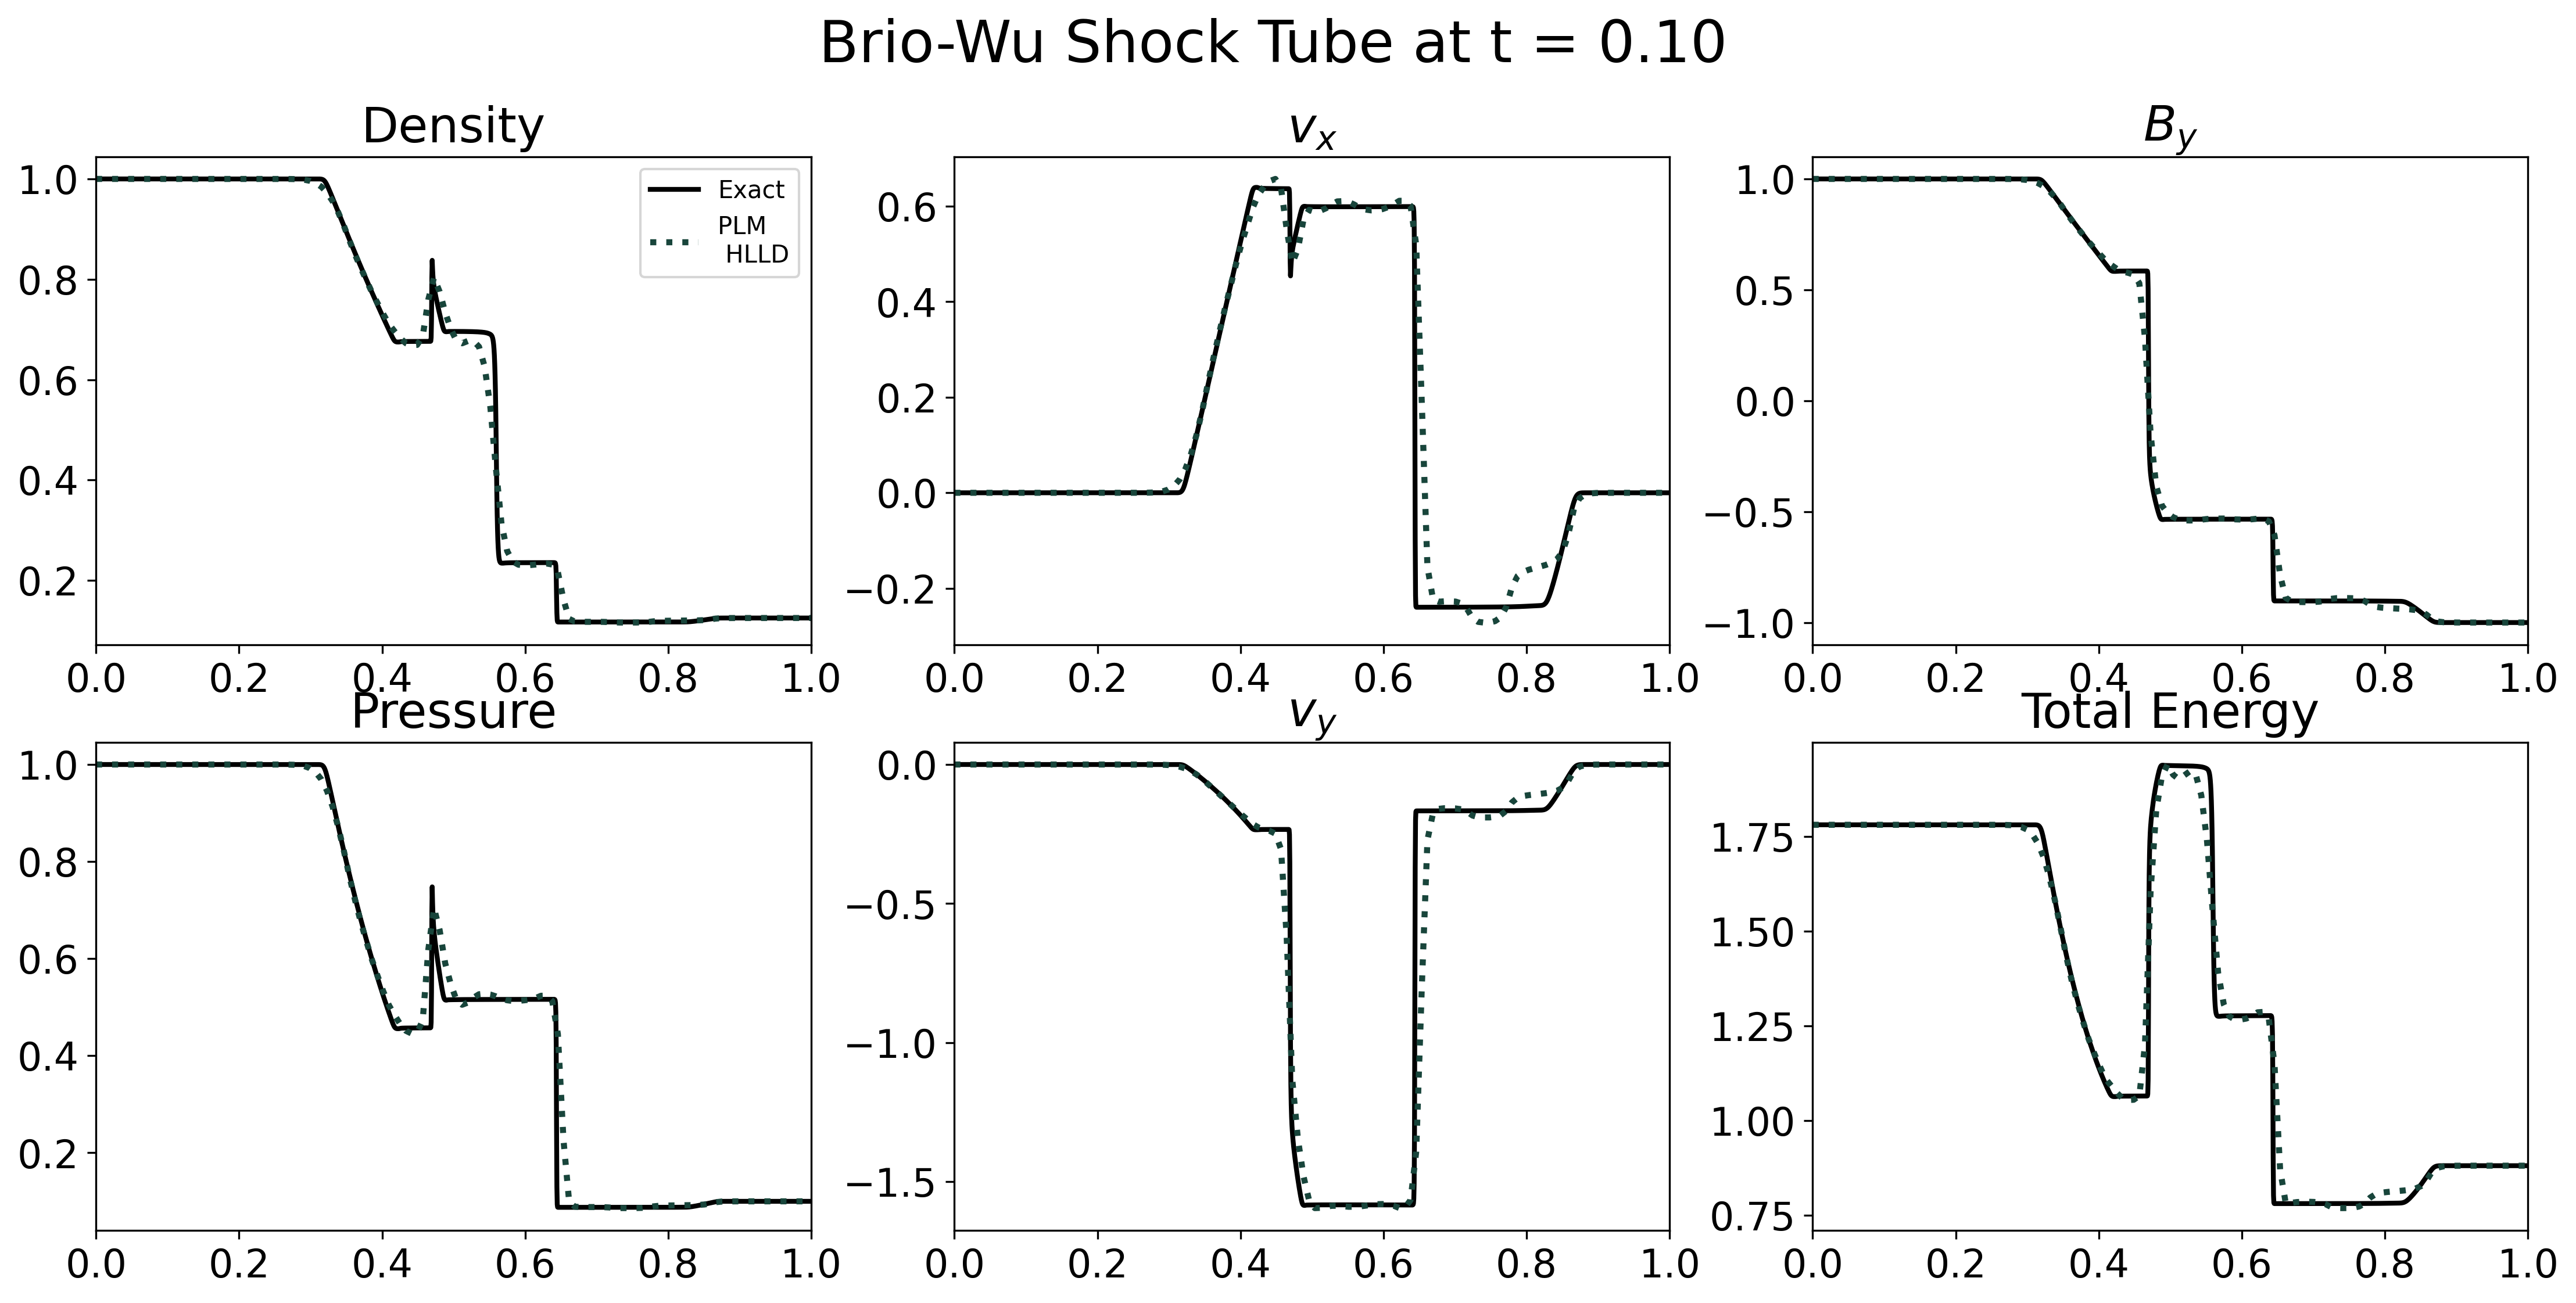

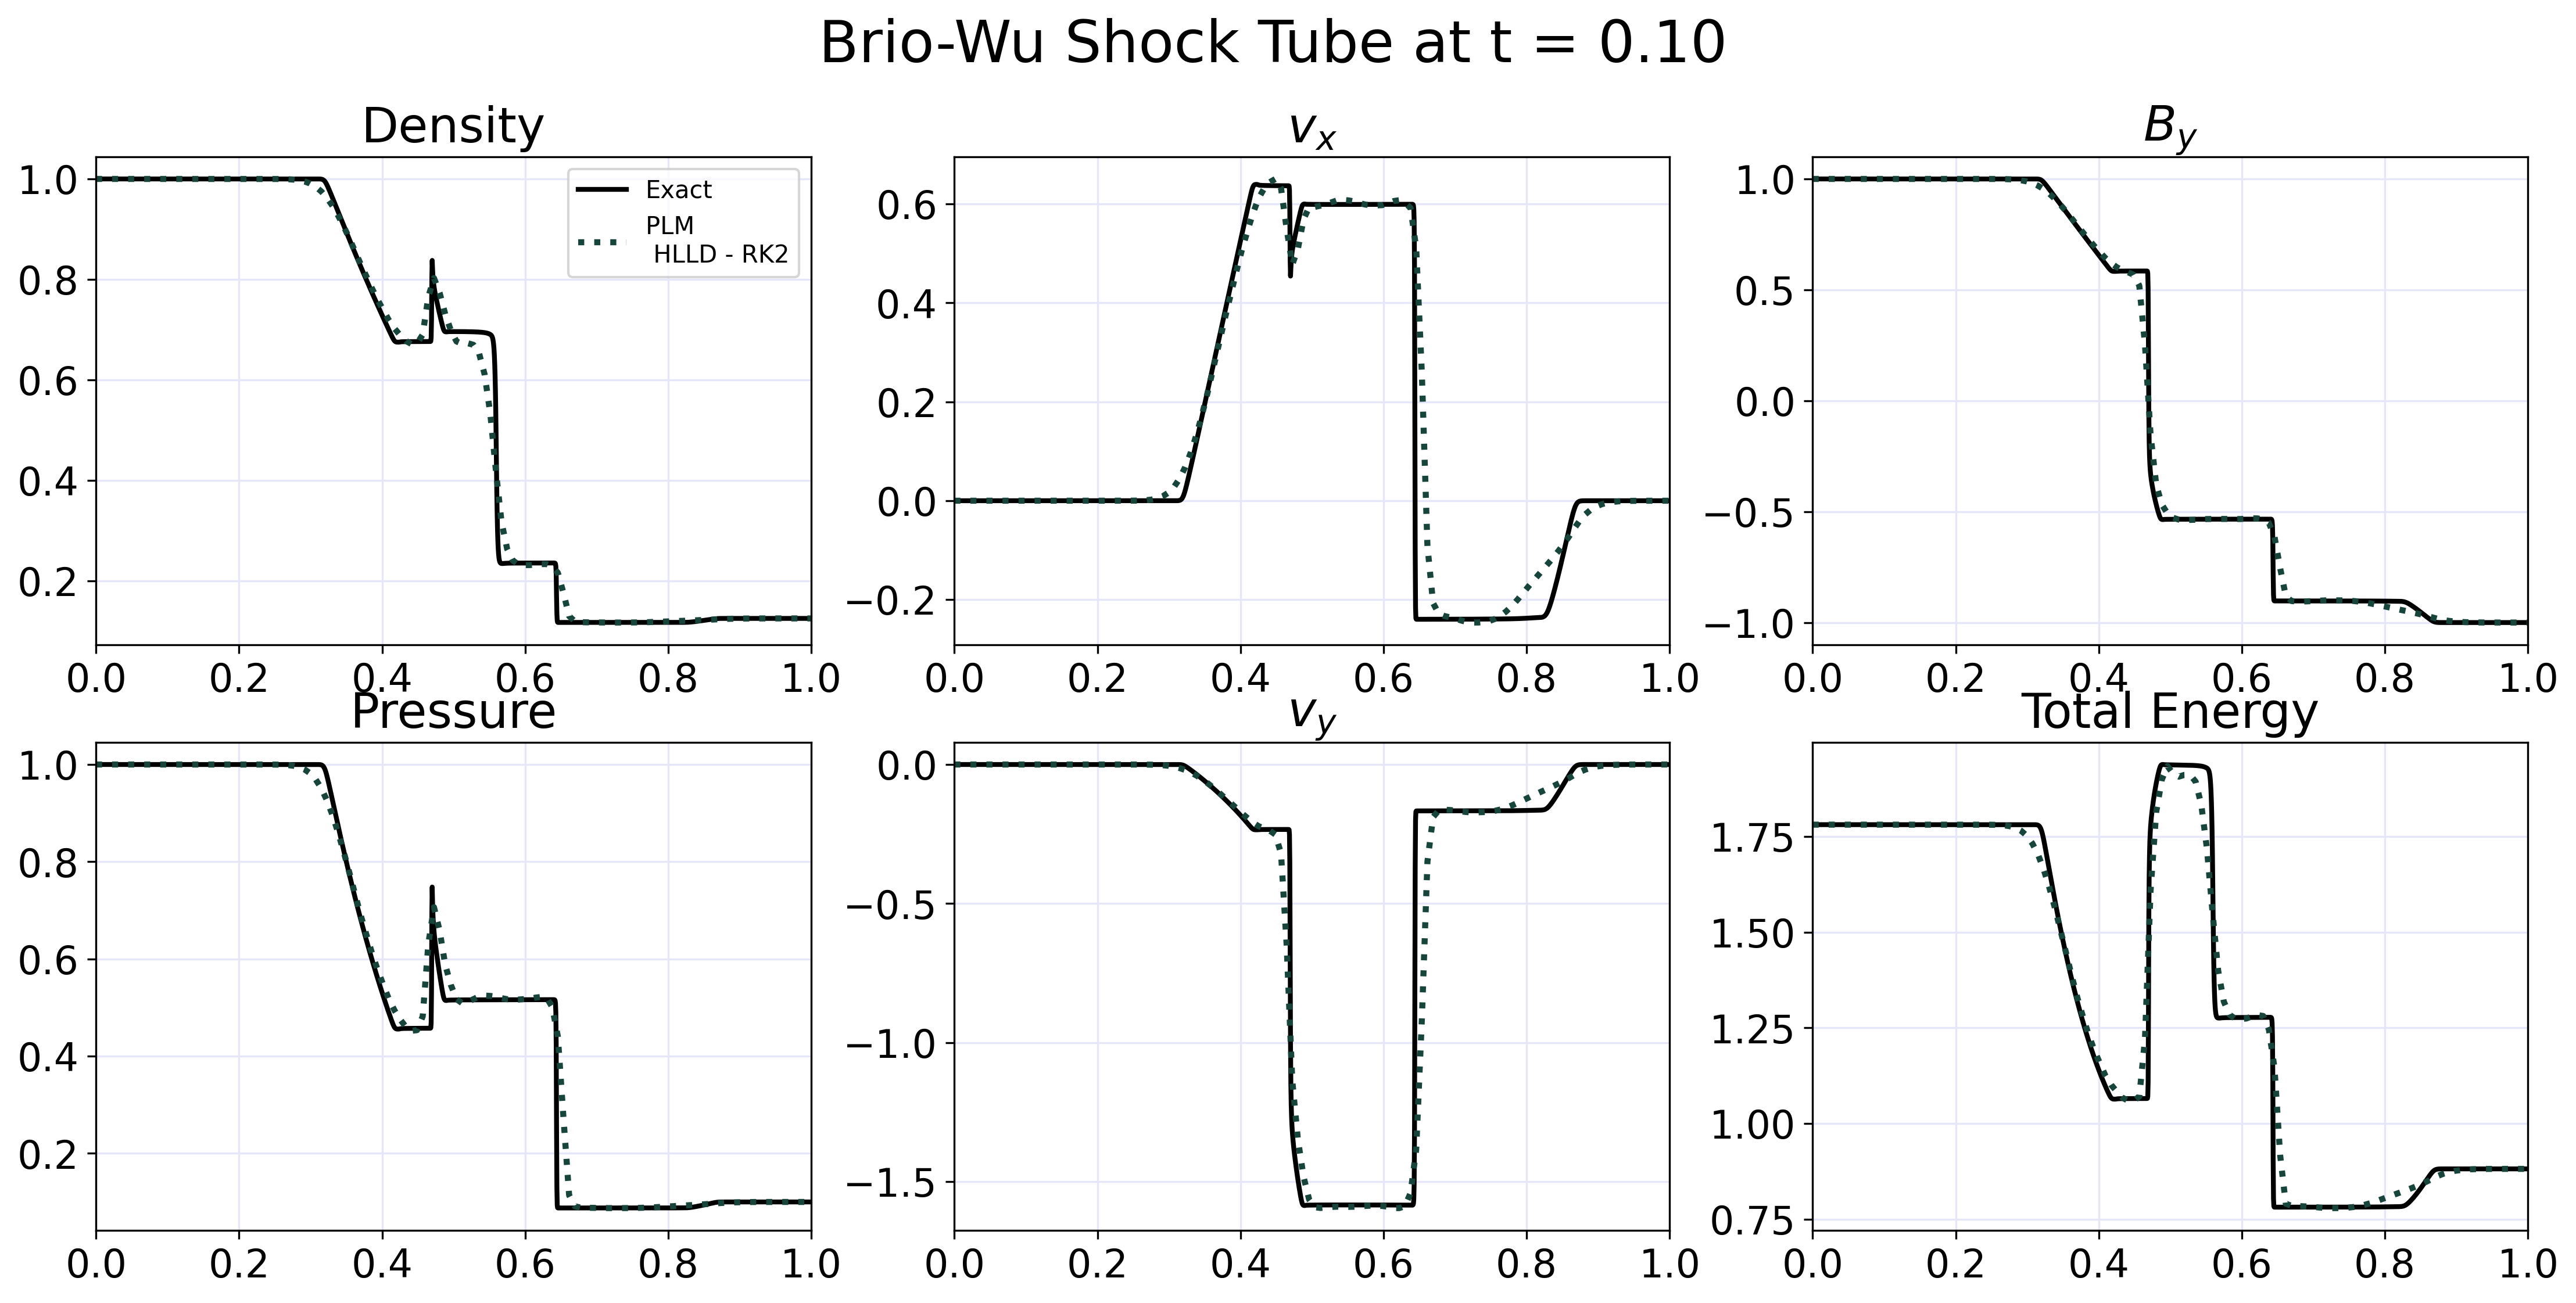

In [21]:
# Brio-Wu problem setting up variables and visualizing

DOFs_MHD_1D = 8
nx = 128
dx = 1/nx
C = 0.4
#Brio-Wu
gamma = 2.0
tf = 0.1

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_BW = np.array([Brio_Wu(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_BW = U_IC_BW.T # shape (DOF, nx)
U_ghost_IC_BW = np.zeros((DOFs_MHD_1D, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_BW[:, nghost:nghost+nx] = U_IC_BW # ghosted vector able to have BCs


U_Sol_BW_g1_HLL, all_solns_BW_g1_HLL, all_t_BW_g1_HLL = evolve(U_ghost_IC_BW, nx, C, tf, gamma, Riemann_HLLD, Godunov_type=1)
U_Sol_BW_g1_HLL_RK2, all_solns_BW_g1_HLL_RK2, all_t_BW_g1_HLL_RK2 = evolve(U_ghost_IC_BW, nx, C, tf, gamma, Riemann_HLLD, Godunov_type=1, RK2=True)


plot_solution(X, U_Sol_BW_g1_HLL, tf, gamma, 'Brio-Wu', 'PLM', 'HLLD')
plot_solution(X, U_Sol_BW_g1_HLL_RK2, tf, gamma, 'Brio-Wu', 'PLM', 'HLLD - RK2')





In [22]:
#movie_maker(X, all_solns_BW_g1_HLL, all_t_BW_g1_HLL, gamma, 'HLL', 'Brio-Wu')

Step: 100, Time: 0.108
Finished at Step: 186, Time: 0.200
Step: 100, Time: 0.108
Finished at Step: 186, Time: 0.200


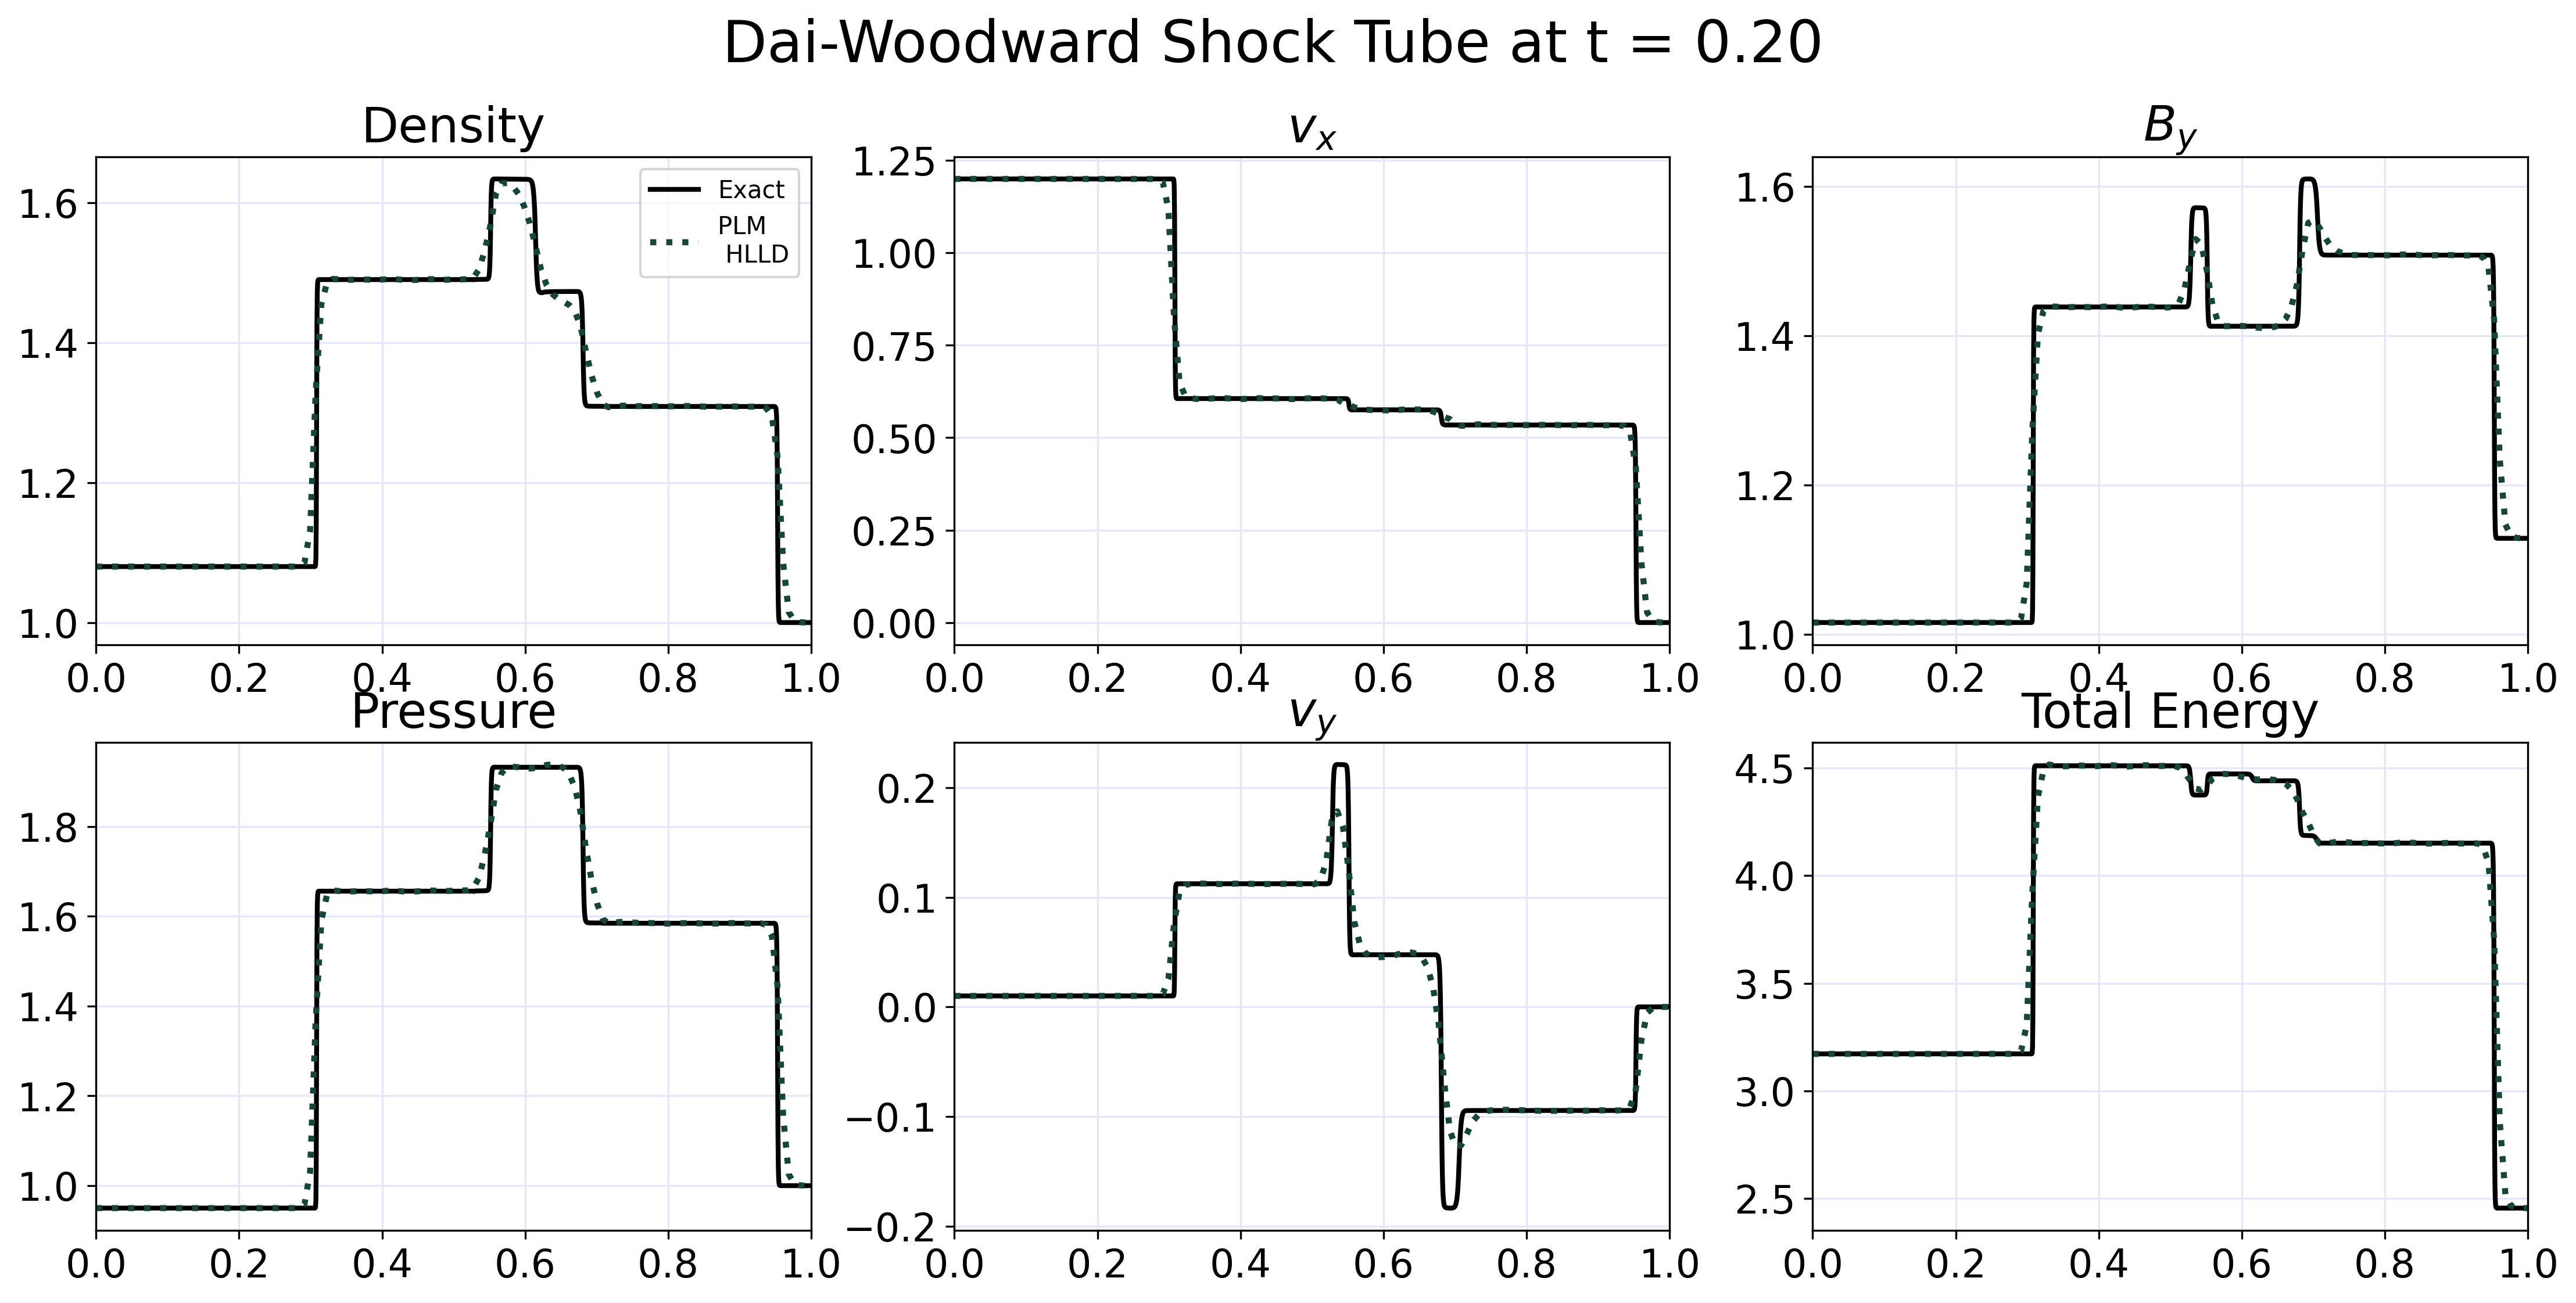

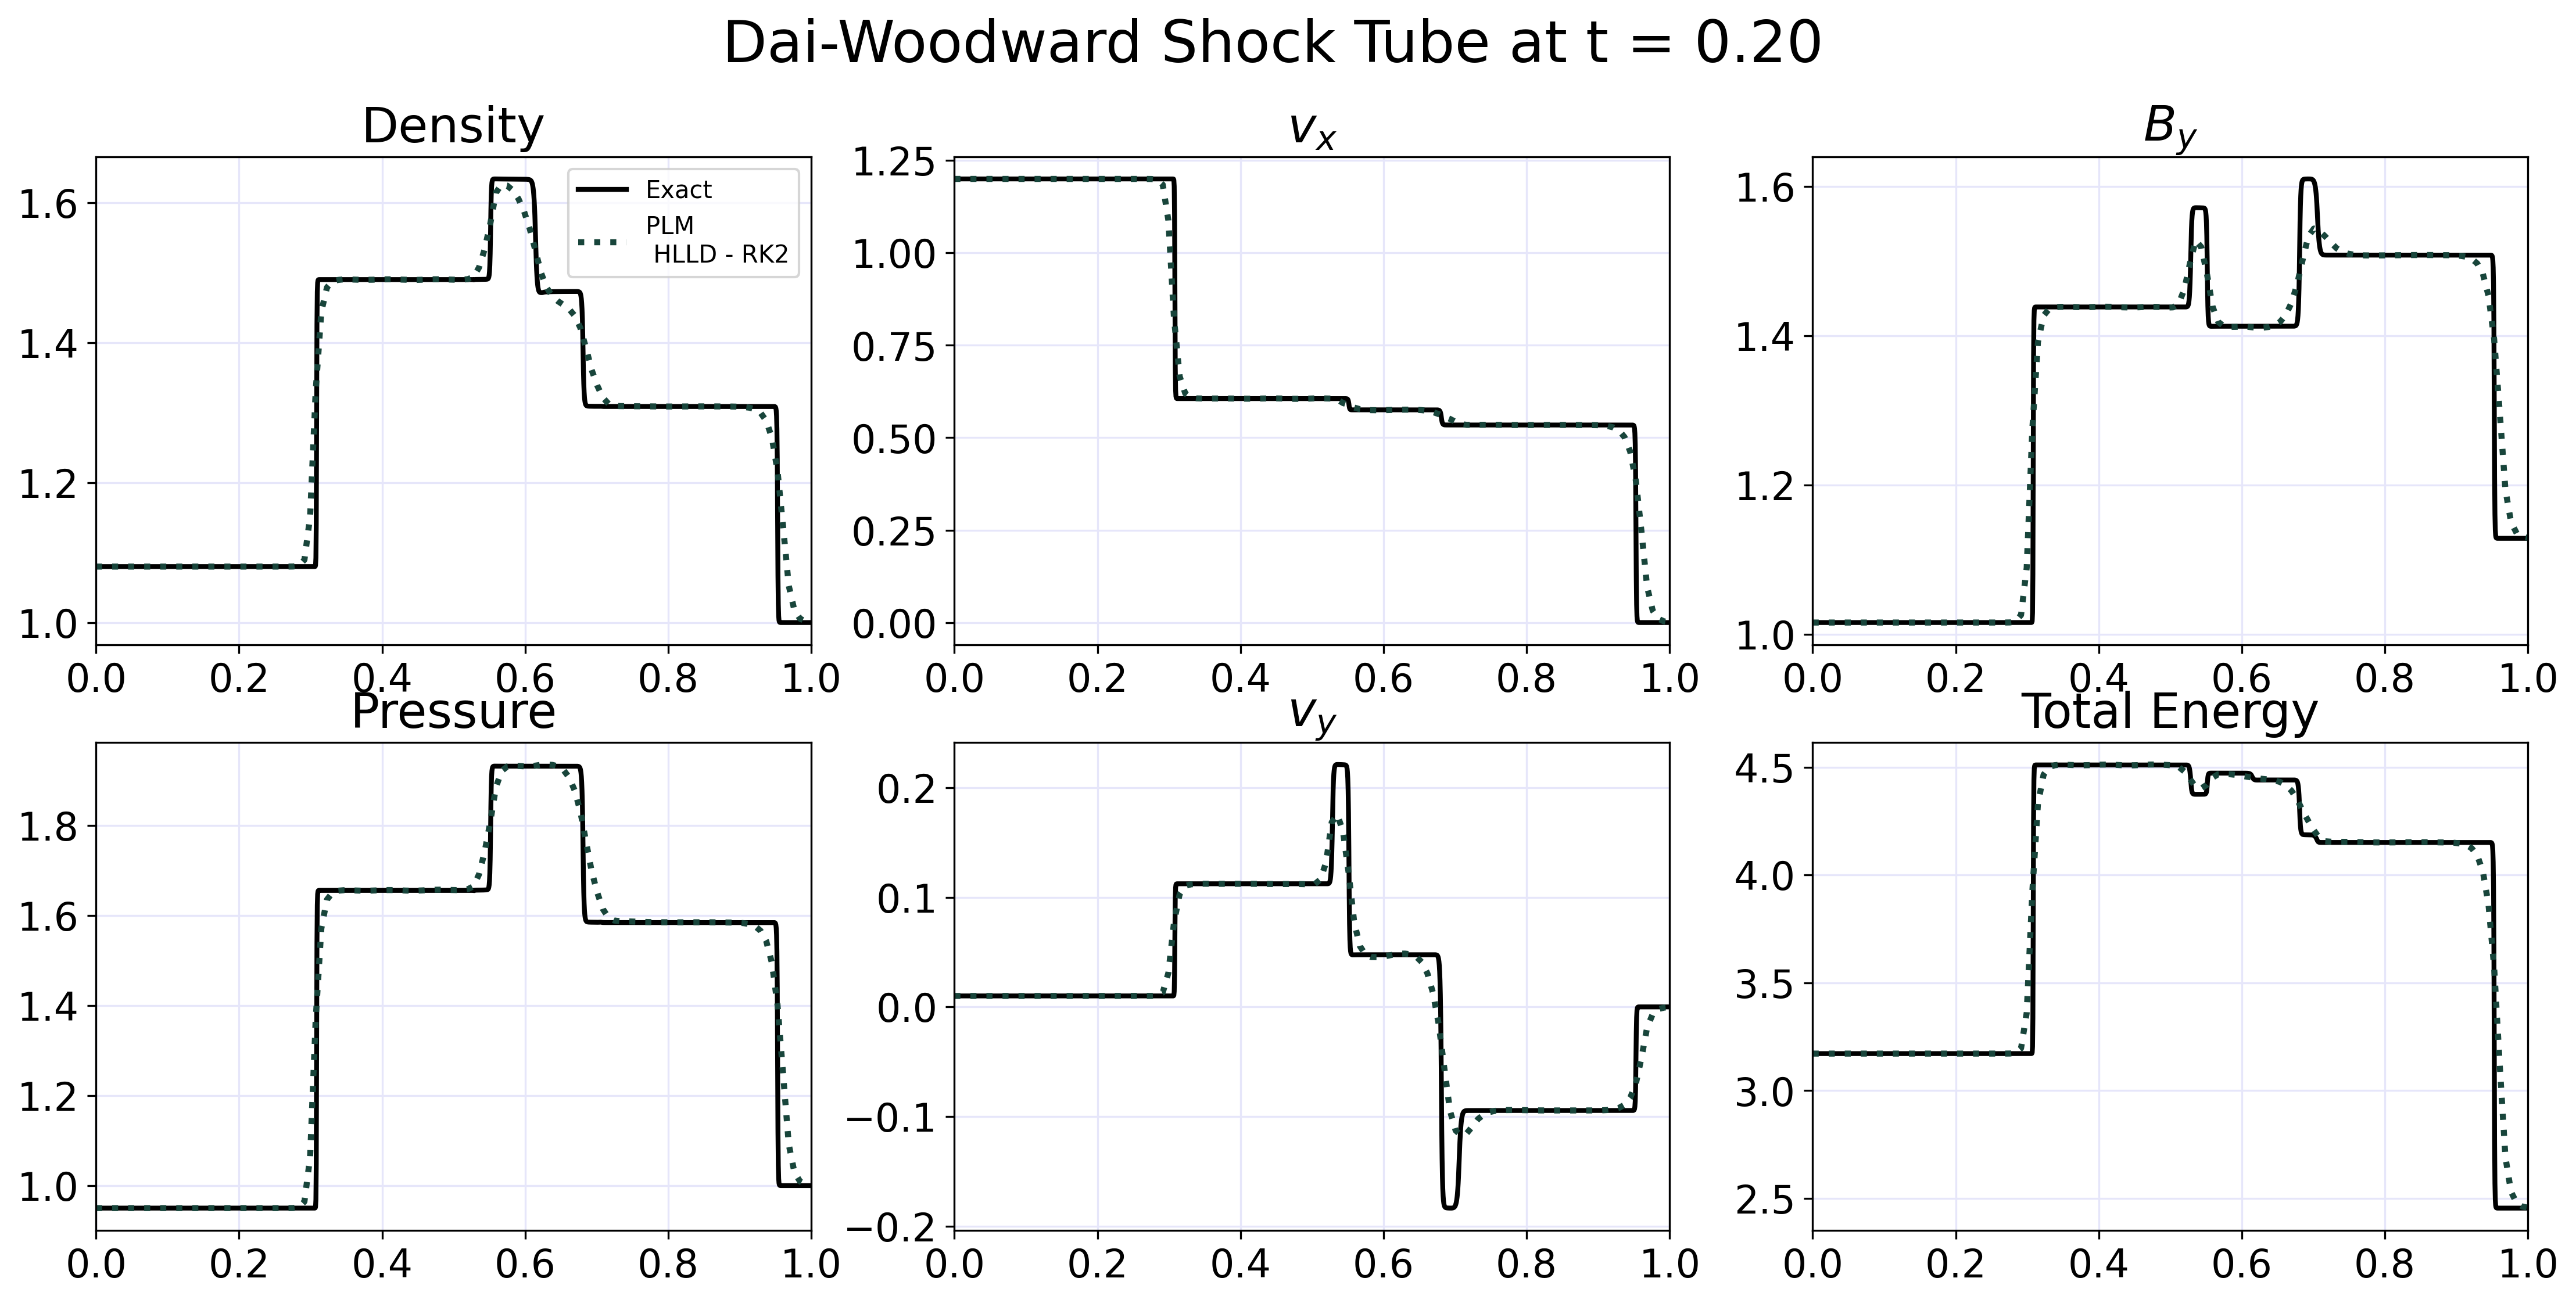

In [23]:
# Dai Woodward problem setting up variables and visualizing

DOFs_MHD_1D = 8
nx = 128
dx = 1/nx
C = 0.4
#Dai-Woodward
gamma = 5/3
tf = 0.2

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_DW = np.array([Dai_Woodward(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_DW = U_IC_DW.T # shape (DOF, nx)
U_ghost_IC_DW = np.zeros((DOFs_MHD_1D, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_DW[:, nghost:nghost+nx] = U_IC_DW # ghosted vector able to have BCs


U_Sol_DW_g1_HLL, all_solns_DW_g1_HLL, all_t_DW_g1_HLL = evolve(U_ghost_IC_DW, nx, C, tf, gamma, Riemann_HLLD, Godunov_type=1)
U_Sol_DW_g1_HLL_RK2, all_solns_DW_g1_HLL_RK2, all_t_DW_g1_HLL_RK2 = evolve(U_ghost_IC_DW, nx, C, tf, gamma, Riemann_HLLD, Godunov_type=1, RK2=True)


plot_solution(X, U_Sol_DW_g1_HLL, tf, gamma, 'Dai-Woodward', 'PLM', 'HLLD')
plot_solution(X, U_Sol_DW_g1_HLL_RK2, tf, gamma, 'Dai-Woodward', 'PLM', 'HLLD - RK2')